# EDA — Pilot NLI Attribution Results  (V2 · reorganised)

**Thesis:** *Measuring In-Context Visibility and Verifiability Across Generative Engines: A Reproducible Multi-Metric Protocol* (BU7170, MSc Business Analytics, Trinity College Dublin).

This is the **reorganised (V2)** exploratory data analysis for the gold-layer artifact
`data/pilot/gold/nli_pilot.parquet` — the measured-once, ready-to-analyse foundation for the
results chapter. It rebuilds the original EDA around three structural fixes:

1. **Search behaviour is promoted to its own section (§4).** Every cross-engine comparison is gated
   on whether the engine *chose to retrieve* at all, so that gate is documented first.
2. **Every headline comparison is shown twice (§5)** — an *unconditional* view (all 1,500 rows) and
   a *conditional* view (cells where the engine searched at least once). The split separates
   "did the engine search?" from "how well did it use what it retrieved?".
3. **The √3 reproducibility ceiling at k = 3 is made visible (§6).**

**Design.** One table, **1,500 rows** = **100 queries × 5 engines × 3 repeats**. Each row is one
AI response with its measured attributes:

| field | meaning |
|---|---|
| `n_response_words`, `n_sentences` | answer length |
| `n_sources_cited`, `n_sources_fetched_ok` | citations made vs. successfully retrieved |
| `ais_supported_sentences`, `ais_rate` | sentences judged supported by sources, and the rate (**verifiability**, RQ4) |
| `pawc_by_source_position`, `pawc_total` | position-weighted supported-word score (**visibility**, RQ1) |
| `nli_evaluations` | number of sentence×source NLI judgements run |
| `engine`, `query_id`, `run_index` | the (engine × query × repeat) keys |

**Metric definitions** (from `thesis_config.py`): `ais_rate = ais_supported_sentences / n_sentences`;
PAWC sums, over *supported* sentences, `word_count × position_weight` with a linear positional decay
(first source = 1.0, last = 1/n). Attribution is by **support** (an NLI entailment classifier reads
each source), making it uniform across all engines.

**Engines** (pilot, listed alphabetically): ChatGPT, Claude, Gemini, Kimi (China), Perplexity (US).
Mistral is reserved for the scale-up. Determinism is handled by the **repeated-measures design**
(k = 3) rather than temperature = 0, which these model generations do not support — so repeat-to-repeat
variation is itself a quantity of interest (§6).

*Note on conventions:* this V2 adopts the alphabetical engine ordering and sentence-case display
labels recommended in the reorganisation review; both are defined **locally** in §0 so
`thesis_config.py` is left untouched.

## 0 · Setup and load

In [1]:
import sys
from pathlib import Path

# Bootstrap the project's single source of truth (thesis_config.py) by walking up.
p = Path.cwd()
while not (p / "thesis_config.py").exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import thesis_config as cfg

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 120)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.5), "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.30,
    "axes.spines.top": False, "axes.spines.right": False,
})

# Cross-cutting conventions (i)+(ii): alphabetical engine order and sentence-case display labels,
# defined locally so thesis_config.py is left untouched. ENGINE_COLORS is keyed by the lowercase
# dataframe key, so ordering is irrelevant to it.
ENGINE_ORDER  = ["chatgpt", "claude", "gemini", "kimi", "perplexity"]
ENGINE_COLORS = {"chatgpt": "#10a37f", "claude": "#d97757", "gemini": "#4285f4",
                 "kimi": "#7c3aed", "perplexity": "#20808d"}
DISPLAY_NAME  = {"chatgpt": "ChatGPT", "claude": "Claude", "gemini": "Gemini",
                 "kimi": "Kimi", "perplexity": "Perplexity"}
ENGINE_LABELS = [DISPLAY_NAME[e] for e in ENGINE_ORDER]   # tick labels, in ENGINE_ORDER
REGION = {"chatgpt": "US", "claude": "US", "gemini": "US", "perplexity": "US", "kimi": "China"}

print(cfg.profile_summary())

RUN PROFILE: PILOT  (N=100, K=3, root=/Users/ganenthraravindran/Desktop/Thesis Data Pilot/data/pilot)


In [2]:
df = pd.read_parquet(cfg.GOLD / "nli_pilot.parquet")
reg = pd.read_parquet(cfg.QUERY_REGISTRY)[["query_id", "query_text", "tags"]]
df = df.merge(reg, on="query_id", how="left")

# Order engines, attach region, and derive a few rates used below.
df["engine"] = pd.Categorical(df["engine"], categories=ENGINE_ORDER, ordered=True)
df["region"] = df["engine"].astype(str).map(REGION)
df["fetch_rate"]         = df.n_sources_fetched_ok / df.n_sources_cited.replace(0, np.nan)
df["words_per_sentence"] = df.n_response_words   / df.n_sentences.replace(0, np.nan)
df["cites_any"]          = df.n_sources_cited > 0

print("rows:", len(df), "| queries:", df.query_id.nunique(),
      "| engines:", list(df.engine.cat.categories), "| repeats:", sorted(df.run_index.unique()))
df.head(3)

rows: 1500 | queries: 100 | engines: ['chatgpt', 'claude', 'gemini', 'kimi', 'perplexity'] | repeats: [np.int64(1), np.int64(2), np.int64(3)]


,n_sentences,n_sources_cited,n_sources_fetched_ok,ais_supported_sentences,ais_rate,pawc_by_source_position,pawc_total,nli_evaluations,input_tokens,output_tokens,engine,query_id,run_index,n_response_words,query_text,tags,region,fetch_rate,words_per_sentence,cites_any
0,6,0,0,0,0.0,"{'3': None, '4': None, '5': None, '6': None, '...",0.000,0,0,0,chatgpt,gb_021e53327e1ee5a9,1,160,why is nitrogen used in plastic welding,"[informational, intermediate, science, technic...",US,NaN,26.666667,False
1,11,8,6,11,1.0,"{'3': 202.0, '4': 163.909, '5': 141.091, '6': ...",795.182,66,0,0,chatgpt,gb_05118b5a6fcf8e43,1,365,art collaborations of 2023,"[informational, simple, arts and entertainment...",US,0.75,33.181818,True
2,2,0,0,0,0.0,"{'3': None, '4': None, '5': None, '6': None, '...",0.000,0,0,0,chatgpt,gb_060a64ae9d5485dc,1,74,Estimate how many times the average human blin...,"[informational, simple, non-technical, questio...",US,NaN,37.000000,False


In [3]:
# Two derived columns added for the reorganised analysis:
#
# (i) searched_any_in_cell — a (query_id, engine)-level gate broadcast to every row: True when ANY
#     of the cell's three repeats returned >=1 citation. This is the filter for the conditional
#     view used throughout §5.
df["searched_any_in_cell"] = (
    df.groupby(["query_id", "engine"], observed=True)["cites_any"].transform("any")
)

# (ii) pawc_words — length-normalised visibility (PAWC per response word); NaN where no words.
df["pawc_words"] = np.where(df.n_response_words == 0, np.nan,
                            df.pawc_total / df.n_response_words.replace(0, np.nan))

# Confirm the cell-level gate aggregates correctly: one value per (query × engine) cell.
cell_gate = df.groupby(["query_id", "engine"], observed=True)["cites_any"].any()
print("(query × engine) cells where searched_any_in_cell == True, per engine "
      "(expected: chatgpt 32, claude 78, gemini 82, kimi 99, perplexity 100):")
print(cell_gate.groupby("engine", observed=True).sum().reindex(ENGINE_ORDER).astype(int).to_string())

(query × engine) cells where searched_any_in_cell == True, per engine (expected: chatgpt 32, claude 78, gemini 82, kimi 99, perplexity 100):
engine
chatgpt        32
claude         78
gemini         82
kimi           99
perplexity    100


## 1 · Dataset integrity

Before any analysis, confirm the artifact *is* the intended 100 × 5 × 3 factorial: every
(query × engine) cell measured exactly three times, no duplicate keys, no missing combinations.

In [4]:
expected = cfg.N_QUERIES * len(ENGINE_ORDER) * cfg.K
dupes    = df.duplicated(["query_id", "engine", "run_index"]).sum()
reps_per_cell = df.groupby(["query_id", "engine"], observed=True).run_index.nunique()

print(f"rows            : {len(df):>5} / expected {expected}   ->  {'OK' if len(df)==expected else 'MISMATCH'}")
print(f"duplicate keys  : {dupes}  (query × engine × repeat)")
print(f"cells != {cfg.K} reps : {(reps_per_cell != cfg.K).sum()} of {reps_per_cell.size}")
print("\ncount by engine × repeat  (each cell should be 100):")
df.groupby(["engine", "run_index"], observed=True).size().unstack("run_index")

rows            :  1500 / expected 1500   ->  OK
duplicate keys  : 0  (query × engine × repeat)
cells != 3 reps : 0 of 500

count by engine × repeat  (each cell should be 100):


run_index,1,2,3
engine,,,
chatgpt,100,100,100
claude,100,100,100
gemini,100,100,100
kimi,100,100,100
perplexity,100,100,100


In [5]:
# Schema at a glance: dtype, null share, cardinality. The artifact is rectangular, so a single
# null column (count + % of 1500) is enough. The two object columns holding dict/list cells
# (pawc_by_source_position, tags) are unhashable, so n_unique is not computed for them; they are
# listed beneath the table rather than shown as NaN.
N = len(df)
UNHASHABLE = ["pawc_by_source_position", "tags"]

def _nulls_str(n):
    return "0" if n == 0 else f"{n} ({n / N * 100:.1f}%)"

info = pd.DataFrame({
    "dtype":             df.dtypes.astype(str),
    "nulls (% of 1500)": {c: _nulls_str(df[c].isna().sum()) for c in df.columns},
    "n_unique":          {c: (np.nan if c in UNHASHABLE else df[c].nunique()) for c in df.columns},
})
display(info.drop(index=UNHASHABLE))
print("object columns containing dict/list — n_unique not computed: " + ", ".join(UNHASHABLE))

,dtype,nulls (% of 1500),n_unique
n_sentences,int64,0,82.0
n_sources_cited,int64,0,25.0
n_sources_fetched_ok,int64,0,23.0
ais_supported_sentences,int64,0,70.0
ais_rate,float64,1 (0.1%),260.0
pawc_total,float64,0,997.0
nli_evaluations,int64,0,302.0
input_tokens,int64,0,1.0
output_tokens,int64,0,1.0
engine,category,0,5.0


object columns containing dict/list — n_unique not computed: pawc_by_source_position, tags


## 2 · Data-quality observations

Four properties of how the data was produced shape its interpretation. **Flags 1–2** are *artifact*
issues that affect **what is measured** (exclude from analysis or treat as null). **Flags 3–4** are
*engine-behaviour* findings that affect **how the measurements should be read**, and are analysed in
full in §4 (search behaviour) and §5 (conditional metrics). Burying flags 3–4 as "caveats" would
hide material results, so they are reported here as observations and carried forward.

In [6]:
print("DATA-QUALITY OBSERVATIONS")
print("=" * 68)

print("\nBLOCK A — Artifact issues (exclude from analysis or treat as null)")
print("-" * 68)
# (1) Token columns are empty in the NLI artifact.
print(f"1. input_tokens / output_tokens nonzero rows : "
      f"{(df.input_tokens != 0).sum()} / {(df.output_tokens != 0).sum()}")
print("   -> all zero here; cost lives in a separate ledger artifact. Exclude from analysis.")
# (2) ais_rate undefined when a response has zero sentences.
print(f"\n2. ais_rate nulls : {df.ais_rate.isna().sum()}  (n_sentences == 0 -> rate undefined)")
if df.ais_rate.isna().any():
    print(df.loc[df.ais_rate.isna(), ["engine", "query_id", "n_sentences", "n_response_words"]]
            .to_string(index=False))

print("\nBLOCK B — Engine-behaviour findings (analysed in §4 and §5)")
print("-" * 68)
# (3) Sentence segmentation: perplexity answers arrive as single blocks.
wps = df.groupby("engine", observed=True).words_per_sentence.median().reindex(ENGINE_ORDER)
print("3. median words-per-sentence by engine (segmentation sanity):")
for e in ENGINE_ORDER:
    print(f"     {DISPLAY_NAME[e]:<11} {wps[e]:5.1f}")
print(f"   -> Perplexity's median is {wps['perplexity']:.1f} words/sentence: responses arrive as single")
print("      blocks rather than sentence-segmented text, so its sentence-level AIS denominator is NOT")
print("      directly comparable to the other four engines. See §5 for the conditional view.")
# (4) Zero-citation prevalence -> structural AIS=0 / PAWC=0 floor (a routing finding).
zc_pct = ((~df.cites_any).groupby(df.engine, observed=True).mean().reindex(ENGINE_ORDER) * 100)
zc_n   = ((~df.cites_any).groupby(df.engine, observed=True).sum().reindex(ENGINE_ORDER).astype(int))
n_cg   = int((df.engine == "chatgpt").sum())
print(f"\n4. ChatGPT cites zero sources on {zc_pct['chatgpt']:.1f}% of responses ({zc_n['chatgpt']}/{n_cg}).")
print("   -> a routing finding (the model often does not search), NOT a measurement failure;")
print("      it sets a STRUCTURAL AIS=0 / PAWC=0 floor. See §4 (search behaviour) and §5 (conditional).")
print("\n   share of zero-citation responses, by engine:")
for e in ENGINE_ORDER:
    print(f"     {DISPLAY_NAME[e]:<11} {zc_pct[e]:5.1f}%  ({zc_n[e]}/{int((df.engine==e).sum())})")

DATA-QUALITY OBSERVATIONS

BLOCK A — Artifact issues (exclude from analysis or treat as null)
--------------------------------------------------------------------
1. input_tokens / output_tokens nonzero rows : 0 / 0
   -> all zero here; cost lives in a separate ledger artifact. Exclude from analysis.

2. ais_rate nulls : 1  (n_sentences == 0 -> rate undefined)
engine            query_id  n_sentences  n_response_words
gemini gb_57e198d356ad745f            0                 0

BLOCK B — Engine-behaviour findings (analysed in §4 and §5)
--------------------------------------------------------------------
3. median words-per-sentence by engine (segmentation sanity):
     ChatGPT      16.5
     Claude       19.5
     Gemini       19.7
     Kimi         16.7
     Perplexity   84.5
   -> Perplexity's median is 84.5 words/sentence: responses arrive as single
      blocks rather than sentence-segmented text, so its sentence-level AIS denominator is NOT
      directly comparable to the other fou

## 3 · Univariate distributions

Shape of each core metric, pooled across all 1,500 responses. Most counts are heavily right-skewed
(a few very long, heavily-cited answers), which justifies reporting medians alongside means and
motivates Spearman over Pearson in §7. Two metrics with a heavy zero mass (`pawc_total`,
`n_response_words`) are also shown on log scale to expose the shape of their non-zero tail.

In [7]:
METRICS = ["n_response_words", "n_sentences", "n_sources_cited", "n_sources_fetched_ok",
           "ais_supported_sentences", "ais_rate", "pawc_total", "nli_evaluations"]
desc = df[METRICS].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc["skew"] = df[METRICS].skew()
desc.round(2)

,count,mean,std,min,5%,25%,50%,75%,95%,max,skew
n_response_words,1500.0,400.67,302.81,0.0,45.95,163.0,333.00,594.25,912.2,3723.00,1.64
n_sentences,1500.0,20.53,18.81,0.0,1.00,4.0,17.00,32.00,51.0,240.00,2.38
n_sources_cited,1500.0,5.84,4.97,0.0,0.00,0.0,6.00,9.00,15.0,24.00,0.70
n_sources_fetched_ok,1500.0,5.05,4.41,0.0,0.00,0.0,5.00,8.00,13.0,24.00,0.73
ais_supported_sentences,1500.0,11.90,15.33,0.0,0.00,0.0,3.00,21.00,43.0,97.00,1.39
ais_rate,1499.0,0.58,0.43,0.0,0.00,0.0,0.75,1.00,1.0,1.00,-0.38
pawc_total,1500.0,546.80,793.99,0.0,0.00,0.0,226.86,807.84,2015.1,5726.96,2.57
nli_evaluations,1500.0,120.41,181.46,0.0,0.00,0.0,24.00,172.50,504.0,1155.00,1.93


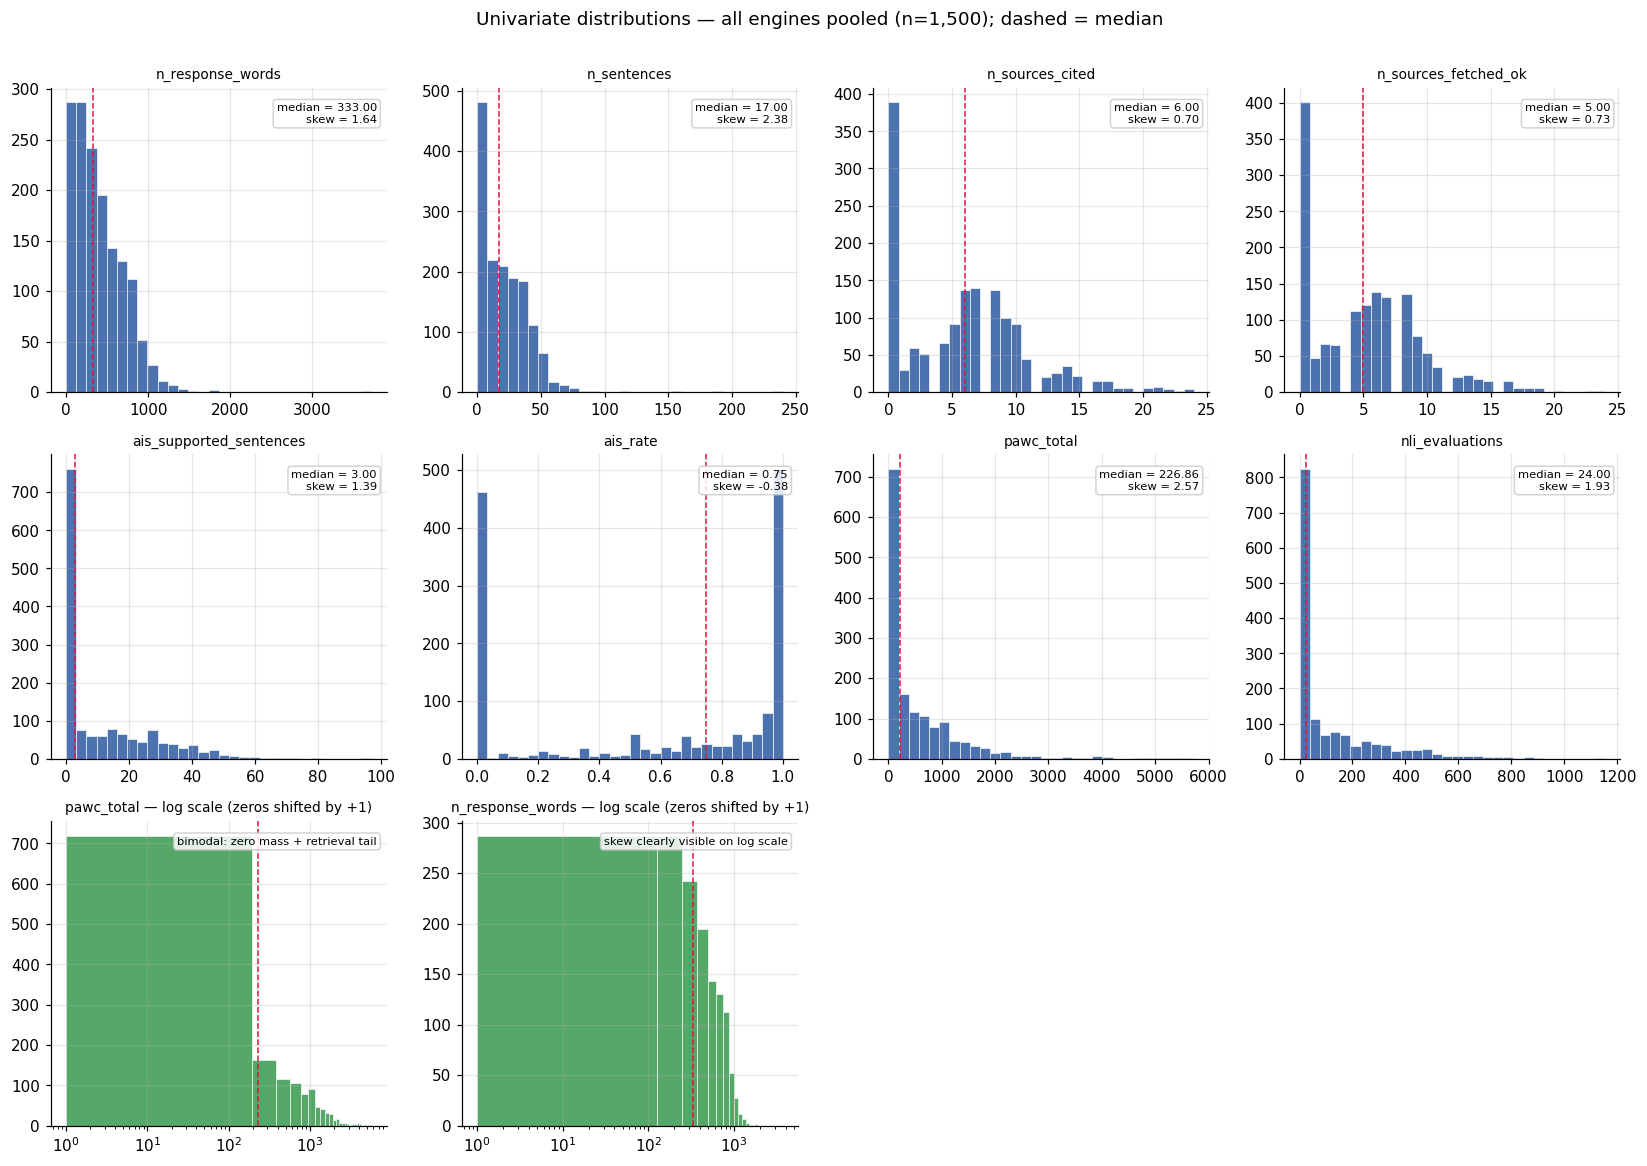

In [8]:
skews = df[METRICS].skew()
meds  = df[METRICS].median()

fig, axes = plt.subplots(3, 4, figsize=(15, 10.5))
# Rows 1-2: the eight metrics on a linear scale, with a median line + a median/skew annotation.
for ax, m in zip(axes[:2].ravel(), METRICS):
    ax.hist(df[m].dropna(), bins=30, color="#4c72b0", edgecolor="white", linewidth=0.4)
    ax.axvline(meds[m], color="crimson", lw=1, ls="--")
    ax.set_title(m, fontsize=9)
    ax.text(0.97, 0.95, f"median = {meds[m]:.2f}\nskew = {skews[m]:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.85))
# Row 3: the two heavy-zero-mass metrics on log scale (zeros shifted by +1).
for ax, m in zip(axes[2, :2], ["pawc_total", "n_response_words"]):
    ax.hist(df[m] + 1, bins=30, color="#55a868", edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
    ax.axvline(meds[m] + 1, color="crimson", lw=1, ls="--")
    ax.set_title(f"{m} — log scale (zeros shifted by +1)", fontsize=9)
for ax in axes[2, 2:]:
    ax.axis("off")
axes[2, 0].text(0.97, 0.95, "bimodal: zero mass + retrieval tail",
                transform=axes[2, 0].transAxes, ha="right", va="top",
                fontsize=7.5,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.85))
axes[2, 1].text(0.97, 0.95, "skew clearly visible on log scale",
                transform=axes[2, 1].transAxes, ha="right", va="top",
                fontsize=7.5,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.85))
fig.suptitle("Univariate distributions — all engines pooled (n=1,500); dashed = median", y=1.005)
fig.tight_layout()
plt.show()

## 4 · Search behaviour across engines

Every cross-engine comparison below is gated on whether the engine chose to search at all. This
section documents that gate. The five engines fall into three search-behaviour bands: always-on
retrieval (Perplexity, Kimi), mostly-on (Claude, Gemini), and off-by-default (ChatGPT). The bands
are not preferences; they are a constitutive property of the cross-engine comparison and determine
whether the unconditional or conditional view of §5 is the methodologically clean comparison.

*Two routing styles emerge from Panel B. Once ChatGPT and Kimi decide to search, they search on all three repeats; the share of search-positive cells that are 3/3 is roughly 75% for ChatGPT and over 97% for Kimi. Claude is similar (~88%). Gemini shows the most genuine routing uncertainty — only ~67% of its search-positive cells are 3/3 — suggesting its decision to invoke the search tool is probabilistic across repeats rather than deterministic. The interpretive implication is that any reproducibility claim for the conditional view will be most defensible for Kimi, Perplexity, and ChatGPT (where routing is binary), and weakest for Gemini.*

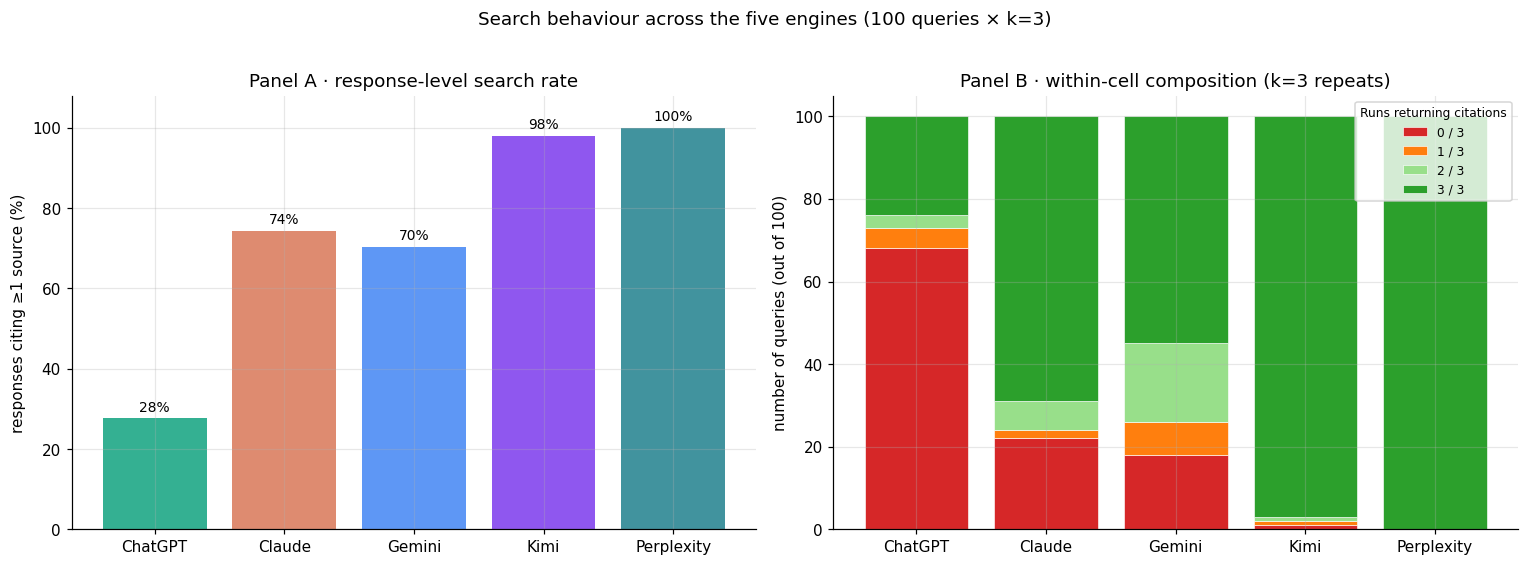

Per-engine search behaviour:
  ChatGPT     search rate  27.7%  |  0/3 =  68 queries   3/3 =  24 queries
  Claude      search rate  74.3%  |  0/3 =  22 queries   3/3 =  69 queries
  Gemini      search rate  70.3%  |  0/3 =  18 queries   3/3 =  55 queries
  Kimi        search rate  98.0%  |  0/3 =   1 queries   3/3 =  97 queries
  Perplexity  search rate 100.0%  |  0/3 =   0 queries   3/3 = 100 queries

Within-cell routing concentration: share of search-positive cells that are 3/3
  ChatGPT      24 of  32 search-positive cells are 3/3  ( 75.0%)
  Claude       69 of  78 search-positive cells are 3/3  ( 88.5%)
  Gemini       55 of  82 search-positive cells are 3/3  ( 67.1%)
  Kimi         97 of  99 search-positive cells are 3/3  ( 98.0%)
  Perplexity  100 of 100 search-positive cells are 3/3  (100.0%)


In [9]:
# Within-cell composition: how many of the k=3 repeats returned >=1 citation, per (query, engine).
runs_citing = (df.groupby(["query_id", "engine"], observed=True)["cites_any"].sum()
                 .rename("n_runs_citing").reset_index())
comp = (runs_citing.groupby(["engine", "n_runs_citing"], observed=True).size()
                   .unstack("n_runs_citing", fill_value=0)
                   .reindex(index=ENGINE_ORDER, columns=[0, 1, 2, 3], fill_value=0))
search_rate = df.groupby("engine", observed=True)["cites_any"].mean().reindex(ENGINE_ORDER)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(ENGINE_ORDER))

# Panel A — response-level search rate per engine.
axA.bar(x, search_rate.values * 100, color=[ENGINE_COLORS[e] for e in ENGINE_ORDER], alpha=0.85)
for i, v in enumerate(search_rate.values * 100):
    axA.text(i, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
axA.set_xticks(x); axA.set_xticklabels(ENGINE_LABELS)
axA.set_ylim(0, 108); axA.set_ylabel("responses citing ≥1 source (%)")
axA.set_title("Panel A · response-level search rate")

# Panel B — within-cell composition (0/3 … 3/3 repeats citing), stacked per engine.
band_colors = ["#d62728", "#ff7f0e", "#98df8a", "#2ca02c"]   # red, orange, light green, dark green
band_labels = ["0 / 3", "1 / 3", "2 / 3", "3 / 3"]
bottom = np.zeros(len(ENGINE_ORDER))
for k, col, lab in zip([0, 1, 2, 3], band_colors, band_labels):
    axB.bar(x, comp[k].values, bottom=bottom, color=col, label=lab, edgecolor="white", linewidth=0.4)
    bottom += comp[k].values
axB.set_xticks(x); axB.set_xticklabels(ENGINE_LABELS)
axB.set_ylabel("number of queries (out of 100)")
axB.set_title("Panel B · within-cell composition (k=3 repeats)")
axB.legend(title="Runs returning citations", fontsize=8, title_fontsize=8)

fig.suptitle("Search behaviour across the five engines (100 queries × k=3)", y=1.02)
fig.tight_layout()
plt.show()

print("Per-engine search behaviour:")
for e in ENGINE_ORDER:
    print(f"  {DISPLAY_NAME[e]:<11} search rate {search_rate[e]*100:5.1f}%  |  "
          f"0/3 = {int(comp.loc[e, 0]):3d} queries   3/3 = {int(comp.loc[e, 3]):3d} queries")

print("\nWithin-cell routing concentration: share of search-positive cells that are 3/3")
for e in ENGINE_ORDER:
    n_pos = int(comp.loc[e, 1] + comp.loc[e, 2] + comp.loc[e, 3])
    n_3of3 = int(comp.loc[e, 3])
    pct = (n_3of3 / n_pos * 100) if n_pos > 0 else float("nan")
    print(f"  {DISPLAY_NAME[e]:<11} {n_3of3:3d} of {n_pos:3d} search-positive cells are 3/3  "
          f"({pct:5.1f}%)")

## 5 · Headline metrics — unconditional and conditional views

The two research metrics live here: **AIS rate** (verifiability, RQ4) and **PAWC total**
(visibility, RQ1). Each is shown twice — *unconditional* (all 1,500 rows) and *conditional* on the
engine having searched at least once in the cell (`searched_any_in_cell == True`, the gate derived
in §0). The split separates two questions the unconditional mean conflates: whether the engine chose
to retrieve, and how well it used what it retrieved.

In [10]:
def engine_summary(frame, with_zero_cite):
    agg = (frame.groupby("engine", observed=True)
                .agg(n=("query_id", "size"),
                     region=("region", "first"),
                     words=("n_response_words", "mean"),
                     sources_cited=("n_sources_cited", "mean"),
                     fetch_rate=("fetch_rate", "mean"),
                     ais_mean=("ais_rate", "mean"),
                     ais_median=("ais_rate", "median"),
                     pawc_mean=("pawc_total", "mean"),
                     pawc_median=("pawc_total", "median"))
                .reindex(ENGINE_ORDER))
    if with_zero_cite:
        agg["pct_zero_cite"] = ((~frame.cites_any).groupby(frame.engine, observed=True)
                                 .mean().reindex(ENGINE_ORDER) * 100)
    agg.index = [DISPLAY_NAME[e] for e in ENGINE_ORDER]
    return agg.round(2)

summary_uncond = engine_summary(df, with_zero_cite=True)
summary_cond   = engine_summary(df[df.searched_any_in_cell], with_zero_cite=False)
summary_uncond = summary_uncond.rename(index={"Perplexity": "Perplexity*"})
summary_cond   = summary_cond.rename(index={"Perplexity": "Perplexity*"})

cells_searched = (df.groupby(["query_id", "engine"], observed=True).cites_any.any()
                    .groupby("engine", observed=True).sum().reindex(ENGINE_ORDER).astype(int))

print("UNCONDITIONAL — all 1,500 responses (100 queries × k=3 per engine):")
display(summary_uncond)
print("CONDITIONAL — restricted to cells where the engine searched at least once across the three "
      "repeats.")
print("  searched (query × engine) cells per engine: "
      + ", ".join(f"{DISPLAY_NAME[e]} {cells_searched[e]}" for e in ENGINE_ORDER))
print("  (pct_zero_cite is meaningless under this filter and is dropped.)")
display(summary_cond)
print('\n* Perplexity\'s sentence-level AIS denominator is not directly comparable to the other '
      'four engines (single-block segmentation, median 84.5 words/sentence — see §2). Compare '
      'Perplexity rows on PAWC and source counts in preference to AIS.')

UNCONDITIONAL — all 1,500 responses (100 queries × k=3 per engine):


,n,region,words,sources_cited,fetch_rate,ais_mean,ais_median,pawc_mean,pawc_median,pct_zero_cite
ChatGPT,300,US,286.98,0.81,0.84,0.14,0.00,55.58,0.00,72.33
Claude,300,US,509.91,4.92,0.86,0.61,0.82,656.60,320.84,25.67
Gemini,300,US,558.90,7.02,0.88,0.56,0.71,544.84,283.07,29.67
Kimi,300,China,484.31,9.35,0.82,0.79,0.93,1059.22,871.24,2.00
Perplexity*,300,US,163.24,7.11,0.91,0.78,1.00,417.75,252.17,0.00


CONDITIONAL — restricted to cells where the engine searched at least once across the three repeats.
  searched (query × engine) cells per engine: ChatGPT 32, Claude 78, Gemini 82, Kimi 99, Perplexity 100
  (pct_zero_cite is meaningless under this filter and is dropped.)


,n,region,words,sources_cited,fetch_rate,ais_mean,ais_median,pawc_mean,pawc_median
ChatGPT,96,US,332.67,2.53,0.84,0.44,0.46,173.69,48.28
Claude,234,US,567.91,6.31,0.86,0.79,0.93,841.80,542.57
Gemini,246,US,549.59,8.56,0.88,0.68,0.85,664.44,459.19
Kimi,297,China,488.68,9.44,0.82,0.79,0.94,1069.92,873.51
Perplexity*,300,US,163.24,7.11,0.91,0.78,1.00,417.75,252.17



* Perplexity's sentence-level AIS denominator is not directly comparable to the other four engines (single-block segmentation, median 84.5 words/sentence — see §2). Compare Perplexity rows on PAWC and source counts in preference to AIS.


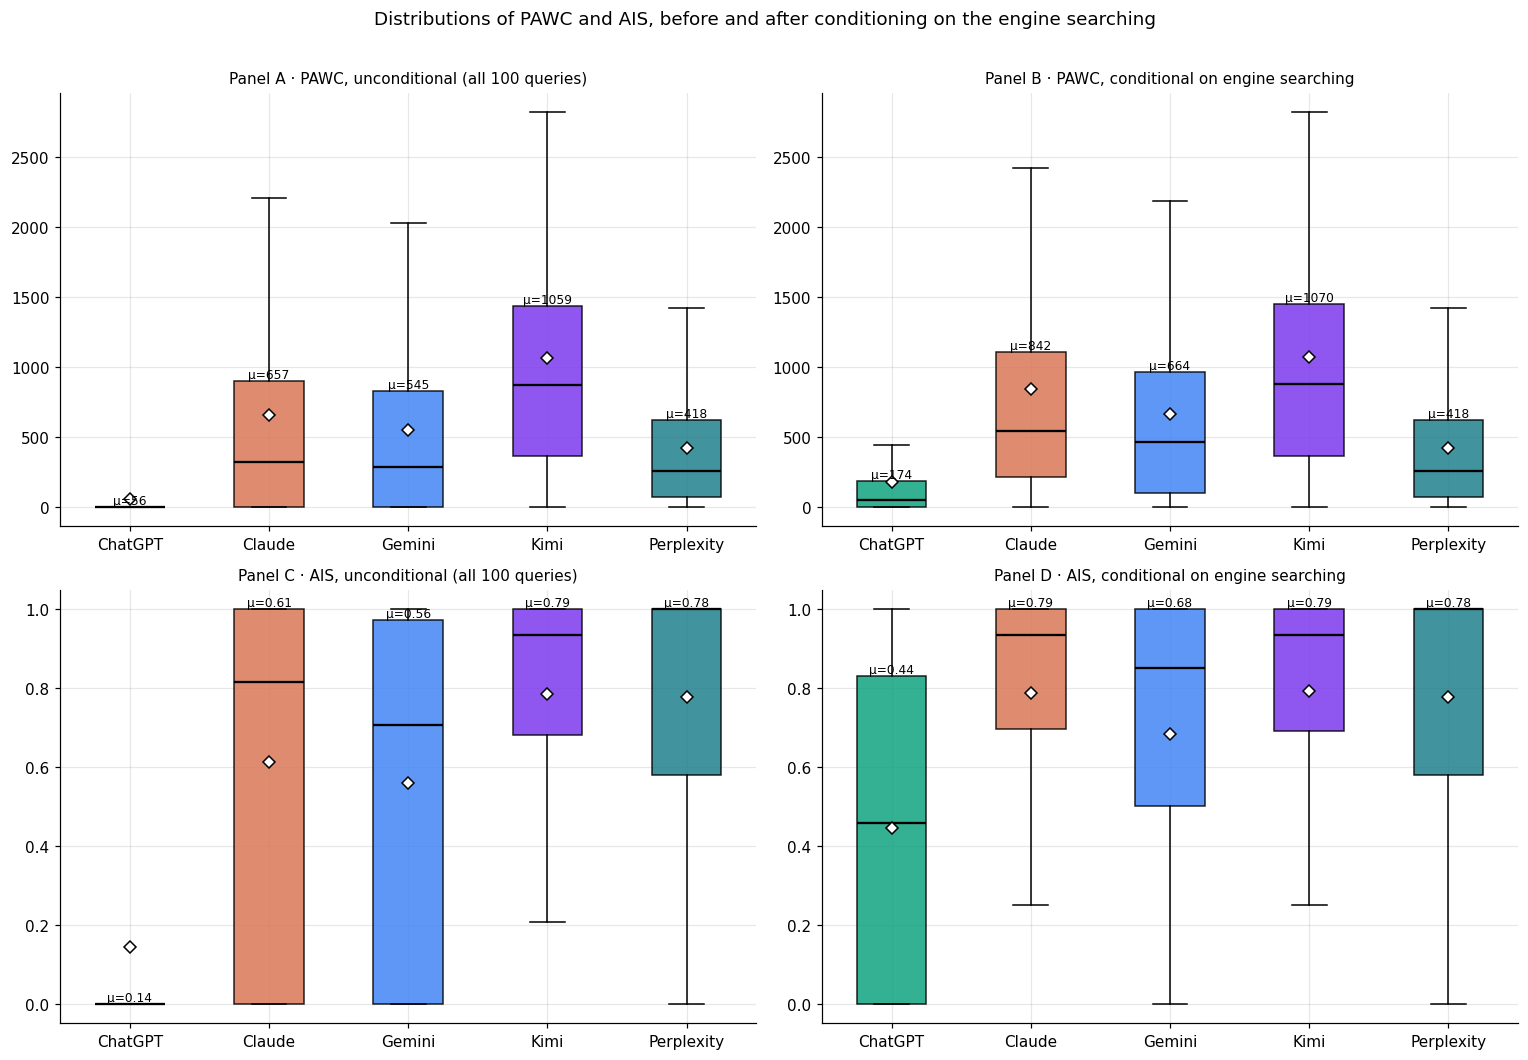

In [11]:
def engine_box(ax, frame, metric, title, fmt):
    data = [frame.loc[frame.engine == e, metric].dropna() for e in ENGINE_ORDER]
    bp = ax.boxplot(data, tick_labels=ENGINE_LABELS, patch_artist=True, showfliers=False,
                    showmeans=True,
                    meanprops=dict(marker="D", markerfacecolor="white",
                                   markeredgecolor="black", markersize=6),
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, e in zip(bp["boxes"], ENGINE_ORDER):
        patch.set_facecolor(ENGINE_COLORS[e]); patch.set_alpha(0.85); patch.set_edgecolor("black")
    for i, e in enumerate(ENGINE_ORDER):
        s = frame.loc[frame.engine == e, metric].dropna()
        if len(s):
            ax.text(i + 1, s.quantile(0.75), ("μ=" + fmt).format(s.mean()),
                    ha="center", va="bottom", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", rotation=0)

cond = df[df.searched_any_in_cell]
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
engine_box(axes[0, 0], df,   "pawc_total", "Panel A · PAWC, unconditional (all 100 queries)", "{:.0f}")
engine_box(axes[0, 1], cond, "pawc_total", "Panel B · PAWC, conditional on engine searching",  "{:.0f}")
engine_box(axes[1, 0], df,   "ais_rate",   "Panel C · AIS, unconditional (all 100 queries)",  "{:.2f}")
engine_box(axes[1, 1], cond, "ais_rate",   "Panel D · AIS, conditional on engine searching",   "{:.2f}")
fig.suptitle("Distributions of PAWC and AIS, before and after conditioning on the engine searching",
             y=1.01)
fig.tight_layout()
plt.show()

ChatGPT's unconditional PAWC and AIS both sit near the floor (≈56 and 0.14) because 72.3% of its
responses return zero citations; conditioning on the cells where it searched lifts its PAWC roughly
threefold (≈56 → ≈174) and its AIS from 0.14 to ≈0.44. The other four engines move far less.
Conditioning *compresses* the top of the AIS leaderboard rather than crowning a single leader:
Kimi (≈0.79), Claude (≈0.79) and Perplexity (≈0.78) converge once routing is controlled for, with
**Claude posting the largest conditional gain** among the always-/mostly-on engines (0.61 → 0.79) —
when it retrieves and cites, its citations are unusually well-supported. Perplexity's AIS remains
subject to the single-block segmentation caveat of §2.

## 6 · Within-cell stability across the k = 3 repeats — and the √3 ceiling

These models cannot be pinned with `temperature=0`, so each cell is measured **3 times** and the
spread is the determinism signal. For every (query × engine) cell the **coefficient of variation**
(CV = sd / mean) across the three repeats is computed, then summarised per engine (lower = steadier).
*In plain terms, a CV of 0.10 means the three repeat values fluctuate by about 10% of their average.*
CV is undefined where the cell mean is 0 (e.g. ChatGPT cells that never cite) and is skipped. With
k = 3 the **maximum attainable CV is √3 ≈ 1.732** — reached when exactly one of the three repeats
returns a non-zero value — so a cell sitting at the ceiling cannot be told apart from genuine high
variance on this evidence alone.

In [12]:
def cv(s):
    m = s.mean()
    return np.nan if (m == 0 or np.isnan(m)) else s.std(ddof=1) / m

cell = df.groupby(["query_id", "engine"], observed=True)
cv_tbl = cell.agg(cv_ais=("ais_rate", cv),
                  cv_pawc=("pawc_total", cv),
                  cv_words=("n_response_words", cv),
                  cv_cited=("n_sources_cited", cv))
per_engine_cv = cv_tbl.groupby("engine", observed=True).mean().reindex(ENGINE_ORDER)
print("Mean within-cell coefficient of variation across the 3 repeats (lower = steadier):")
display(per_engine_cv.round(3).rename(index=DISPLAY_NAME))

# Share of *eligible* cells (those with a defined CV) sitting exactly at the √3 ceiling.
SQRT3 = np.sqrt(3); _TGT = round(SQRT3, 3)
def _ceil_pct(s):
    v = s.dropna()
    return (v.round(3) == _TGT).mean() * 100 if len(v) else np.nan
ceiling_share = (cv_tbl.reset_index().groupby("engine", observed=True)
                       .agg(ais_ceil_pct=("cv_ais", _ceil_pct),
                            pawc_ceil_pct=("cv_pawc", _ceil_pct))
                       .reindex(ENGINE_ORDER))
print("\nShare of eligible cells at the √3 ≈ 1.732 ceiling (per engine, % of non-null CVs):")
print(ceiling_share.round(1).rename(index=DISPLAY_NAME).to_string())

Mean within-cell coefficient of variation across the 3 repeats (lower = steadier):


,cv_ais,cv_pawc,cv_words,cv_cited
engine,,,,
ChatGPT,0.853,0.935,0.138,0.545
Claude,0.246,0.379,0.098,0.222
Gemini,0.512,0.703,0.115,0.546
Kimi,0.205,0.428,0.147,0.197
Perplexity,0.348,0.659,0.135,0.047



Share of eligible cells at the √3 ≈ 1.732 ceiling (per engine, % of non-null CVs):
            ais_ceil_pct  pawc_ceil_pct
engine                                 
ChatGPT             30.0           30.0
Claude               5.2            5.2
Gemini              12.3           12.3
Kimi                 2.0            2.0
Perplexity          10.4           10.4


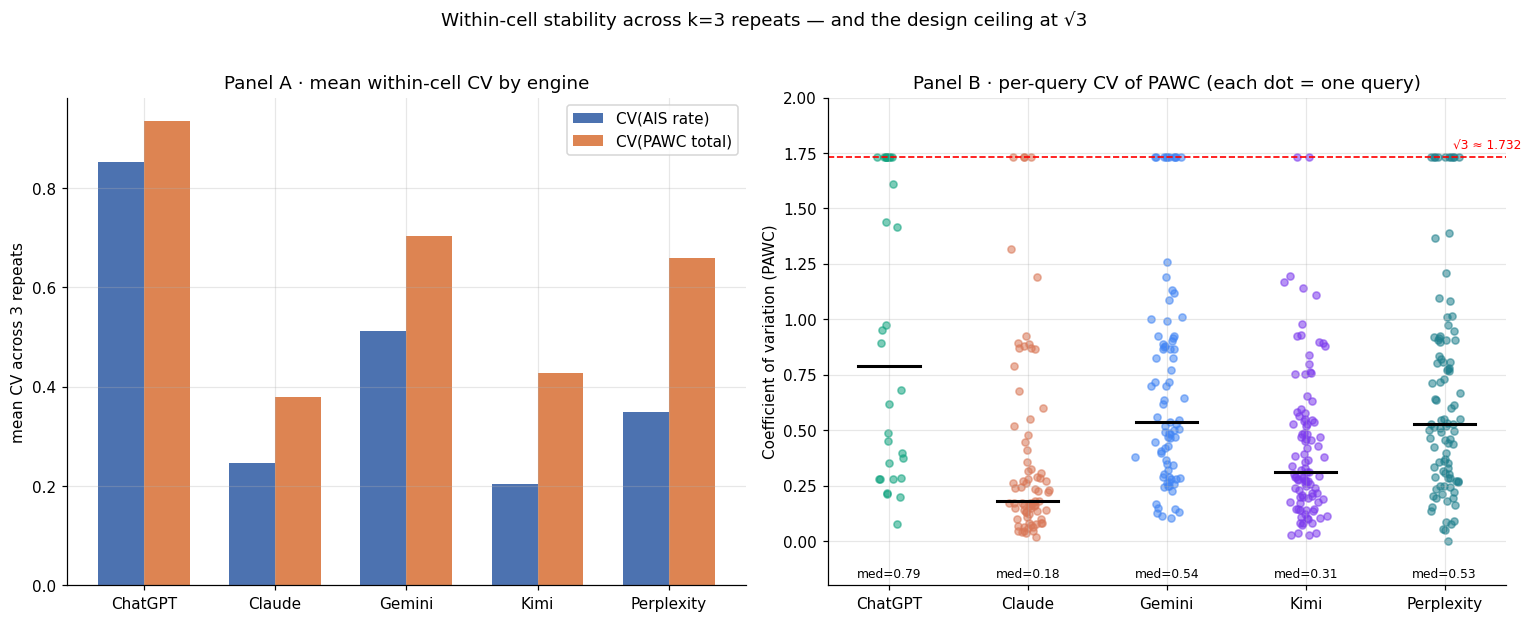

In [13]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(ENGINE_ORDER))

# Panel A — mean within-cell CV per engine, for AIS and PAWC.
w = 0.35
axA.bar(x - w/2, per_engine_cv.cv_ais.values,  w, label="CV(AIS rate)",   color="#4c72b0")
axA.bar(x + w/2, per_engine_cv.cv_pawc.values, w, label="CV(PAWC total)", color="#dd8452")
axA.set_xticks(x); axA.set_xticklabels(ENGINE_LABELS)
axA.set_ylabel("mean CV across 3 repeats"); axA.legend()
axA.set_title("Panel A · mean within-cell CV by engine")

# Panel B — per-query CV of PAWC (each dot = one cell), jittered, with median bar + √3 ceiling.
rng = np.random.default_rng(cfg.SEED)
cvp = cv_tbl.reset_index()
for i, e in enumerate(ENGINE_ORDER):
    vals = cvp.loc[cvp.engine == e, "cv_pawc"].dropna().values
    axB.scatter(np.full(len(vals), i) + rng.normal(0, 0.06, len(vals)), vals,
                alpha=0.55, s=22, color=ENGINE_COLORS[e])
    med = np.median(vals) if len(vals) else np.nan
    axB.plot([i - 0.22, i + 0.22], [med, med], color="black", lw=2)
    axB.text(i, -0.12, f"med={med:.2f}", ha="center", va="top", fontsize=8)
axB.axhline(SQRT3, color="red", linestyle="--", linewidth=1.1)
axB.text(len(ENGINE_ORDER) - 0.45, SQRT3 + 0.02, "√3 ≈ 1.732", color="red",
         ha="right", va="bottom", fontsize=8)
axB.set_xticks(x); axB.set_xticklabels(ENGINE_LABELS)
axB.set_ylim(-0.2, 2.0); axB.set_ylabel("Coefficient of variation (PAWC)")
axB.set_title("Panel B · per-query CV of PAWC (each dot = one query)")
fig.suptitle("Within-cell stability across k=3 repeats — and the design ceiling at √3", y=1.02)
fig.tight_layout()
plt.show()

Approximately **9.1%** of eligible cells (those with a defined CV) sit exactly at the √3 ≈ 1.732
ceiling — **30.0% for ChatGPT, 12.3% for Gemini, and 10.4% for Perplexity**. The ChatGPT and Gemini
shares are at least partly a routing artefact: a CV at the ceiling arises when exactly one of three
repeats returns a non-zero value, which is the structural signature of binary tool routing.
Perplexity, however, searches on every call — its 10.4% ceiling rate cannot be explained by routing
instability and must reflect genuine support-level variance across the three repeats. This is the
cleanest single-engine evidence in the pilot that k = 3 is too small to distinguish routing variance
from substantive retrieval variance, and provides direct empirical support, within the pilot data
itself, for the published **k ≥ 7 minimum (Schulte et al. 2026)** that the scale-up adopts (k = 8).
Note also that the AIS-ceiling and PAWC-ceiling shares are identical for every engine: the ceiling
pattern is determined by which runs searched at all, which sets both AIS and PAWC to zero or
non-zero together. The two ceilings are not independent variance findings.

## 7 · Metric relationships

How the metrics move together. Expected structure: response length drives sentence count and NLI
workload; `pawc_total` tracks supported sentences; `fetch_rate` exposes how often cited URLs actually
retrieve. Correlations use **Spearman** (rank) rather than Pearson because §3 documented pronounced
right-skew, which violates Pearson's bivariate-normality assumption.

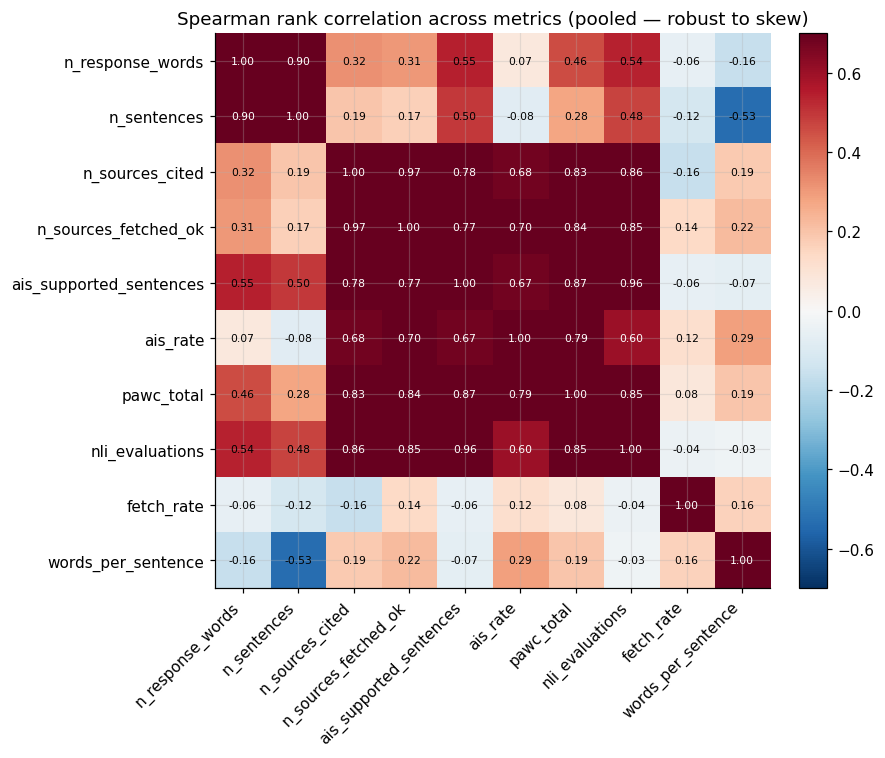

In [14]:
corr = df[METRICS + ["fetch_rate", "words_per_sentence"]].corr(method="spearman", numeric_only=True)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-0.7, vmax=0.7)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(corr.iloc[i, j]) > 0.55 else "black")
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Spearman rank correlation across metrics (pooled — robust to skew)")
fig.tight_layout()
plt.show()

Spearman rather than Pearson because §3 documented skews ranging from **0.70** (`n_sources_cited`)
to **2.57** (`pawc_total`) — with `ais_rate` the only negatively-skewed metric (−0.38) — which violate
Pearson's bivariate-normality assumption. Rank correlation is robust to this.

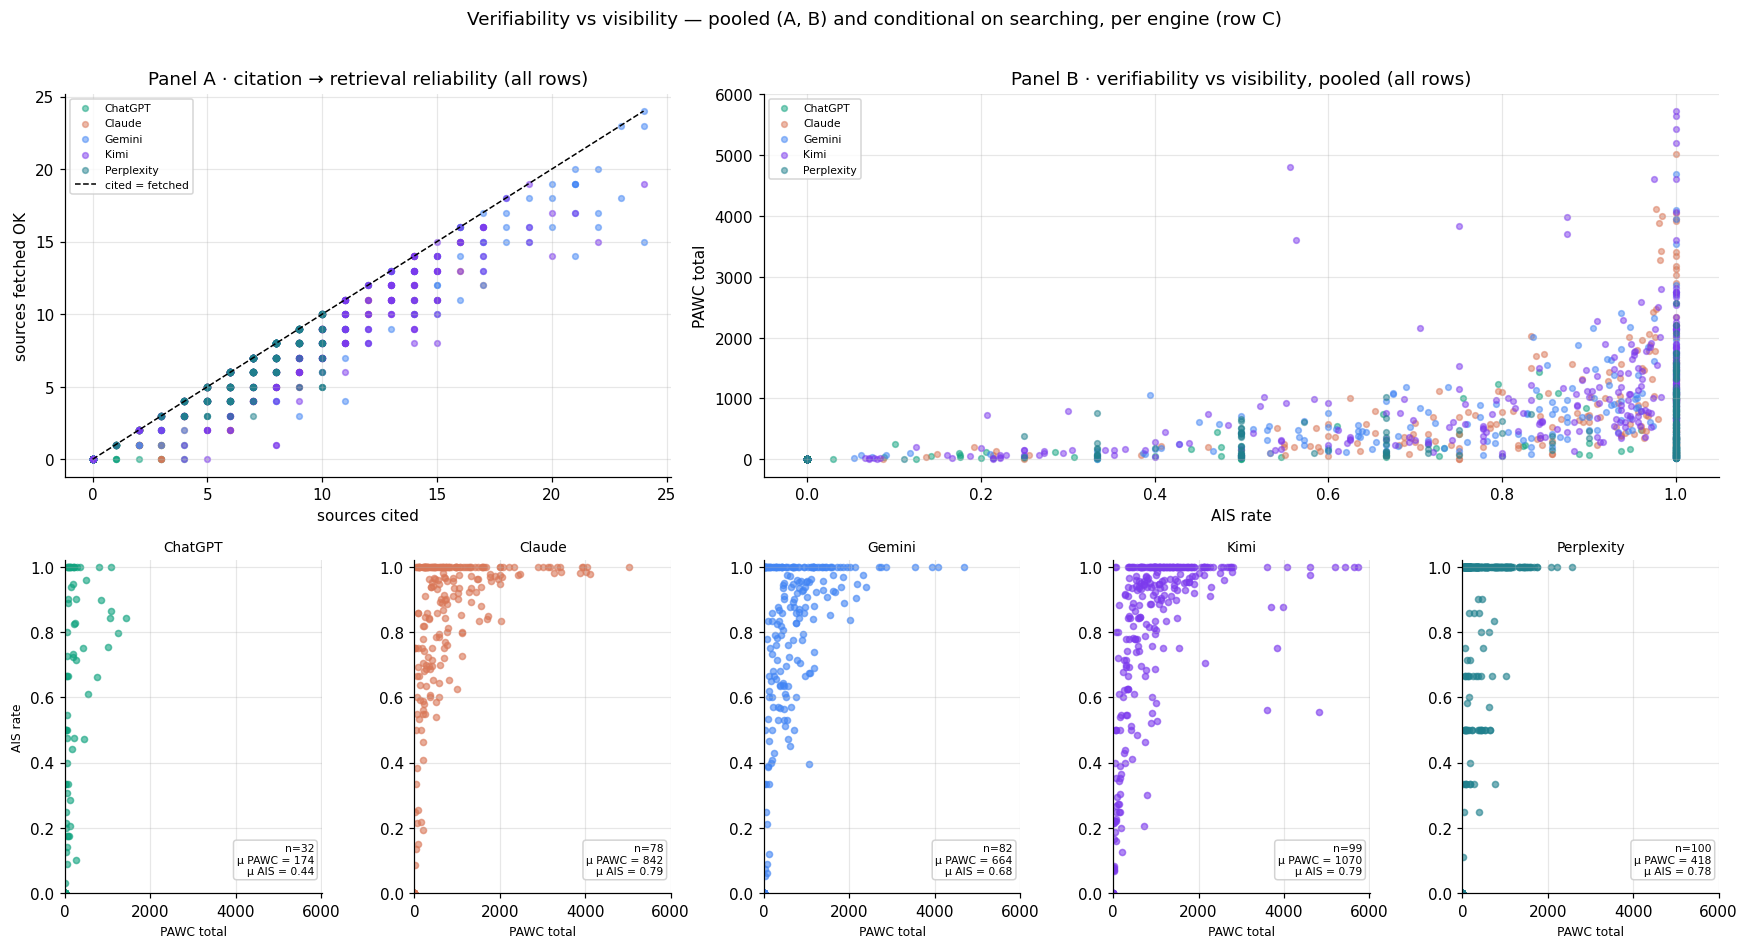

In [15]:
cond = df[df.searched_any_in_cell]
fig, axd = plt.subplot_mosaic(
    [["A", "A", "B", "B", "B"],
     ["c0", "c1", "c2", "c3", "c4"]],
    figsize=(16, 8.5), height_ratios=[1.15, 1.0])

# Panel A — citation -> retrieval reliability (all 1,500 rows).
axA = axd["A"]
for e in ENGINE_ORDER:
    s = df[df.engine == e]
    axA.scatter(s.n_sources_cited, s.n_sources_fetched_ok, s=14, alpha=0.5,
                color=ENGINE_COLORS[e], label=DISPLAY_NAME[e])
lim = df.n_sources_cited.max()
axA.plot([0, lim], [0, lim], "k--", lw=1, label="cited = fetched")
axA.set(xlabel="sources cited", ylabel="sources fetched OK",
        title="Panel A · citation → retrieval reliability (all rows)")
axA.legend(fontsize=7)

# Panel B — AIS vs PAWC, pooled (all 1,500 rows).
axB = axd["B"]
for e in ENGINE_ORDER:
    s = df[df.engine == e]
    axB.scatter(s.ais_rate, s.pawc_total, s=14, alpha=0.5, color=ENGINE_COLORS[e], label=DISPLAY_NAME[e])
axB.set(xlabel="AIS rate", ylabel="PAWC total",
        title="Panel B · verifiability vs visibility, pooled (all rows)")
axB.legend(fontsize=7)

# Panel C — AIS vs PAWC conditional on searching, one small multiple per engine (shared limits).
xmax = cond.pawc_total.max() * 1.05
for key, e in zip(["c0", "c1", "c2", "c3", "c4"], ENGINE_ORDER):
    ax = axd[key]
    s = cond[cond.engine == e]
    ax.scatter(s.pawc_total, s.ais_rate, s=16, alpha=0.6, color=ENGINE_COLORS[e])
    mu_pawc = s.pawc_total.mean() if len(s) else np.nan
    mu_ais  = s.ais_rate.mean()   if len(s) else np.nan
    n_cells = s.query_id.nunique()
    ax.text(0.97, 0.05,
            f"n={n_cells}\nμ PAWC = {mu_pawc:.0f}\nμ AIS = {mu_ais:.2f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.85))
    ax.set_title(DISPLAY_NAME[e], fontsize=9)
    ax.set_xlim(0, xmax); ax.set_ylim(0, 1.02)
    ax.set_xlabel("PAWC total", fontsize=8)
    if key == "c0":
        ax.set_ylabel("AIS rate", fontsize=8)
fig.suptitle("Verifiability vs visibility — pooled (A, B) and conditional on searching, per engine (row C)",
             y=1.01)
fig.tight_layout()
plt.show()

## 8 · Query-level signal

Pooling across engines and repeats: which prompts are hardest to support well, and do the GEO-Bench
query **tags** (intent, difficulty, topic sensitivity) move the metrics? Tags with fewer than five
distinct queries are dropped from the effect chart — their 95% CIs are too wide to interpret. (In
this pilot every listed axis tag clears that threshold, so none are dropped here; the guard matters
for the scale-up.)

In [16]:
qlevel = (df.groupby("query_id", observed=True)
            .agg(query_text=("query_text", "first"),
                 mean_ais=("ais_rate", "mean"),
                 mean_pawc=("pawc_total", "mean"),
                 mean_cited=("n_sources_cited", "mean")))
print("Hardest queries to support (lowest mean AIS across all engines):")
display(qlevel.sort_values("mean_ais").head(8).round(2))

Hardest queries to support (lowest mean AIS across all engines):


,query_text,mean_ais,mean_pawc,mean_cited
query_id,,,,
gb_47da164820de8d87,What is the difference between you and a human?,0.05,61.99,1.27
gb_2770c3b815282630,Write a sentence with all words starting with ...,0.20,13.80,1.60
gb_1eb0f99fd07a05d4,what is the funnest terraria class,0.21,56.95,5.47
gb_5b95c1501647091c,account/microsoft/login,0.23,222.68,5.13
gb_fdf7a01aad9a65c5,Should there be limits on military spending?,0.26,106.08,5.27
gb_634fd8ff74ccf265,Make a reservation for two at an Italian resta...,0.27,92.87,6.93
gb_e78889de403c8eaa,http://www.rewardclub.me/,0.28,80.64,4.33
gb_588d144b9e0f9869,who sings the christmas song all i want for ch...,0.28,21.58,2.93


In [17]:
# Break the metrics down along a few interpretable tag axes (only tags that appear are shown).
tag_df = df.explode("tags")
AXES = {
    "intent":      ["informational", "transactional", "navigational"],
    "difficulty":  ["simple", "intermediate", "complex"],
    "tech":        ["technical", "non-technical"],
    "sensitivity": ["sensitive", "non-sensitive"],
    "format":      ["question", "fact", "opinion", "debate"],
}
rows = []
for axis, vals in AXES.items():
    for v in vals:
        sub = tag_df[tag_df.tags == v]
        if len(sub):
            rows.append({"axis": axis, "tag": v, "n_rows": len(sub),
                         "mean_ais": sub.ais_rate.mean(), "mean_pawc": sub.pawc_total.mean(),
                         "mean_cited": sub.n_sources_cited.mean()})
pd.DataFrame(rows).set_index(["axis", "tag"]).round(2)

n_rows  mean_ais  mean_pawc  mean_cited
axis        tag                                                   
intent      informational    1125      0.58     575.70        5.85
            transactional     165      0.51     614.78        5.66
            navigational       90      0.60     245.16        6.26
difficulty  simple            735      0.57     373.17        5.35
            intermediate      480      0.57     675.57        6.18
            complex           135      0.66    1234.85        7.33
tech        technical         210      0.58     768.09        6.02
            non-technical    1155      0.58     525.45        5.80
sensitivity sensitive         195      0.54     566.13        5.97
            non-sensitive    1035      0.58     603.76        5.93
format      question         1005      0.59     550.04        5.90
            fact              495      0.58     511.47        5.50
            opinion           300      0.53     586.06        5.97
            debate            240      0.53     568.80        5.76

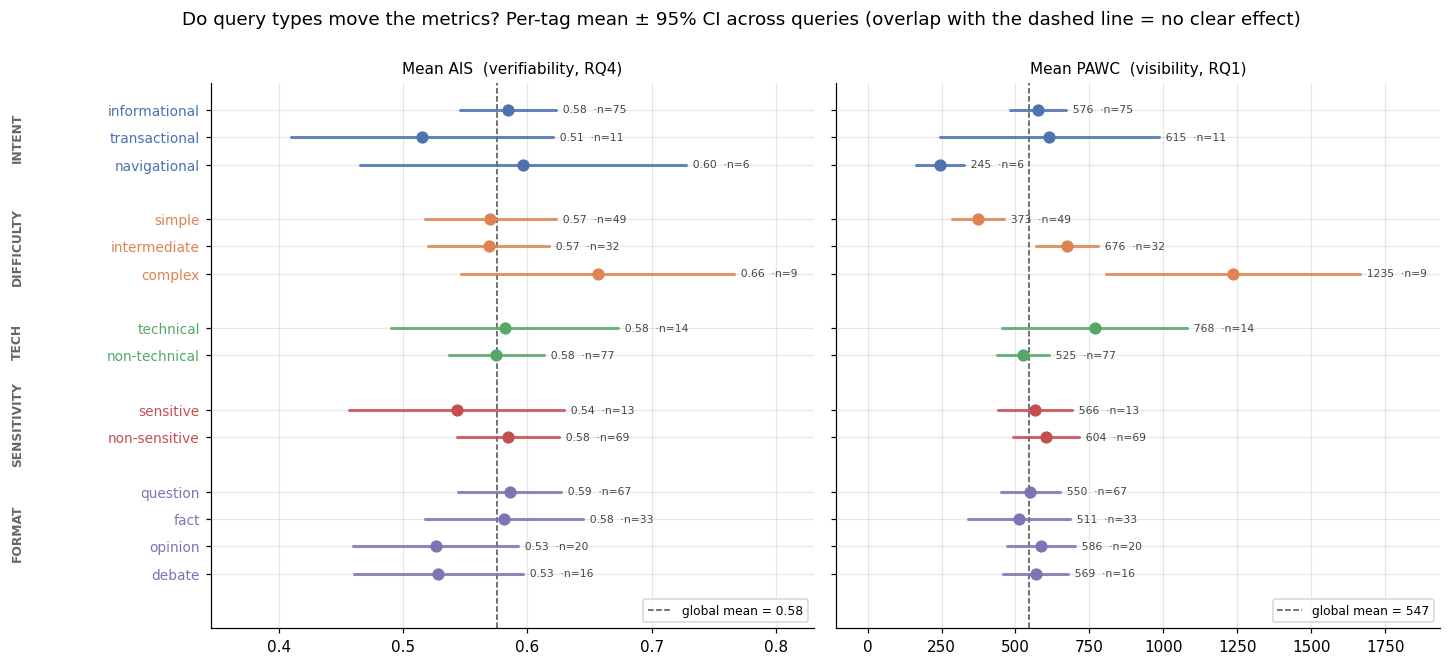

In [18]:
# Visualise the tag-axis table above as effect plots: per-tag mean +/- 95% CI for each research
# metric, against the global mean. CIs are taken across QUERIES (the honest unit): collapse the
# 15 rows/query (5 engines x 3 repeats) to a per-query mean first, else the CI is ~15x too narrow.
qm = (tag_df.groupby(["tags", "query_id"], observed=True)
            .agg(ais=("ais_rate", "mean"), pawc=("pawc_total", "mean"))
            .reset_index())

# Drop tags with fewer than five distinct queries (their 95% CIs are too wide to interpret).
tag_query_counts = qm.groupby("tags", observed=True).query_id.nunique()
eligible_tags = set(tag_query_counts[tag_query_counts >= 5].index)
qm = qm[qm["tags"].isin(eligible_tags)]

eff = []
for axis, vals in AXES.items():
    for v in vals:
        sub = qm[qm["tags"] == v]
        nq = len(sub)
        if nq == 0:
            continue
        row = {"axis": axis, "tag": v, "n": nq}
        for metric in ("ais", "pawc"):
            m, se = sub[metric].mean(), sub[metric].sem()
            half = 1.96 * se if nq > 1 else np.nan      # n=1 -> point only, no interval
            row[f"{metric}_mean"], row[f"{metric}_lo"], row[f"{metric}_hi"] = m, m - half, m + half
        eff.append(row)
eff = pd.DataFrame(eff)

# y-layout: tags top-to-bottom grouped by axis, with a blank gap between axes.
AXIS_COLORS = {"intent": "#4c72b0", "difficulty": "#dd8452", "tech": "#55a868",
               "sensitivity": "#c44e52", "format": "#8172b3"}
ypos, ylabels, ycolors, axis_spans = {}, [], [], []
y = 0
for axis in AXES:                                       # preserve AXES order
    present = eff[eff.axis == axis]["tag"].tolist()
    if not present:
        continue
    start = y
    for tag in present:
        ypos[tag] = y; ylabels.append(tag); ycolors.append(AXIS_COLORS[axis]); y += 1
    axis_spans.append((axis, start, y - 1))
    y += 1                                              # gap between axes
ymax = y

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
panels = [("ais", "Mean AIS  (verifiability, RQ4)", df.ais_rate.mean()),
          ("pawc", "Mean PAWC  (visibility, RQ1)", df.pawc_total.mean())]
for ax, (metric, title, gmean) in zip(axes, panels):
    glabel = f"global mean = {gmean:.2f}" if metric == "ais" else f"global mean = {gmean:.0f}"
    ax.axvline(gmean, color="black", ls="--", lw=1, alpha=0.7, label=glabel)
    for _, r in eff.iterrows():
        yy, c = ypos[r["tag"]], AXIS_COLORS[r["axis"]]
        lo, hi, mn = r[f"{metric}_lo"], r[f"{metric}_hi"], r[f"{metric}_mean"]
        if not np.isnan(lo):
            ax.plot([lo, hi], [yy, yy], color=c, lw=2, alpha=0.85, solid_capstyle="round")
        ax.plot(mn, yy, "o", color=c, ms=7, zorder=3)
        note = (f"  {mn:.2f}" if metric == "ais" else f"  {mn:.0f}") + f"  ·n={int(r['n'])}"
        ax.text(hi if not np.isnan(hi) else mn, yy, note, va="center", ha="left",
                fontsize=7, color="#444444")
    ax.set_yticks(list(ypos.values())); ax.set_yticklabels(ylabels, fontsize=9)
    for tl, c in zip(ax.get_yticklabels(), ycolors):
        tl.set_color(c)
    ax.set_ylim(-1, ymax); ax.invert_yaxis()
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8, loc="lower right"); ax.margins(x=0.18)
for axis, lo_y, hi_y in axis_spans:
    axes[0].text(-0.32, (lo_y + hi_y) / 2, axis.upper(), transform=axes[0].get_yaxis_transform(),
                 rotation=90, va="center", ha="center", fontsize=8, fontweight="bold", color="#666666")
fig.suptitle("Do query types move the metrics? Per-tag mean ± 95% CI across queries "
             "(overlap with the dashed line = no clear effect)", y=1.00)
fig.tight_layout()
plt.show()

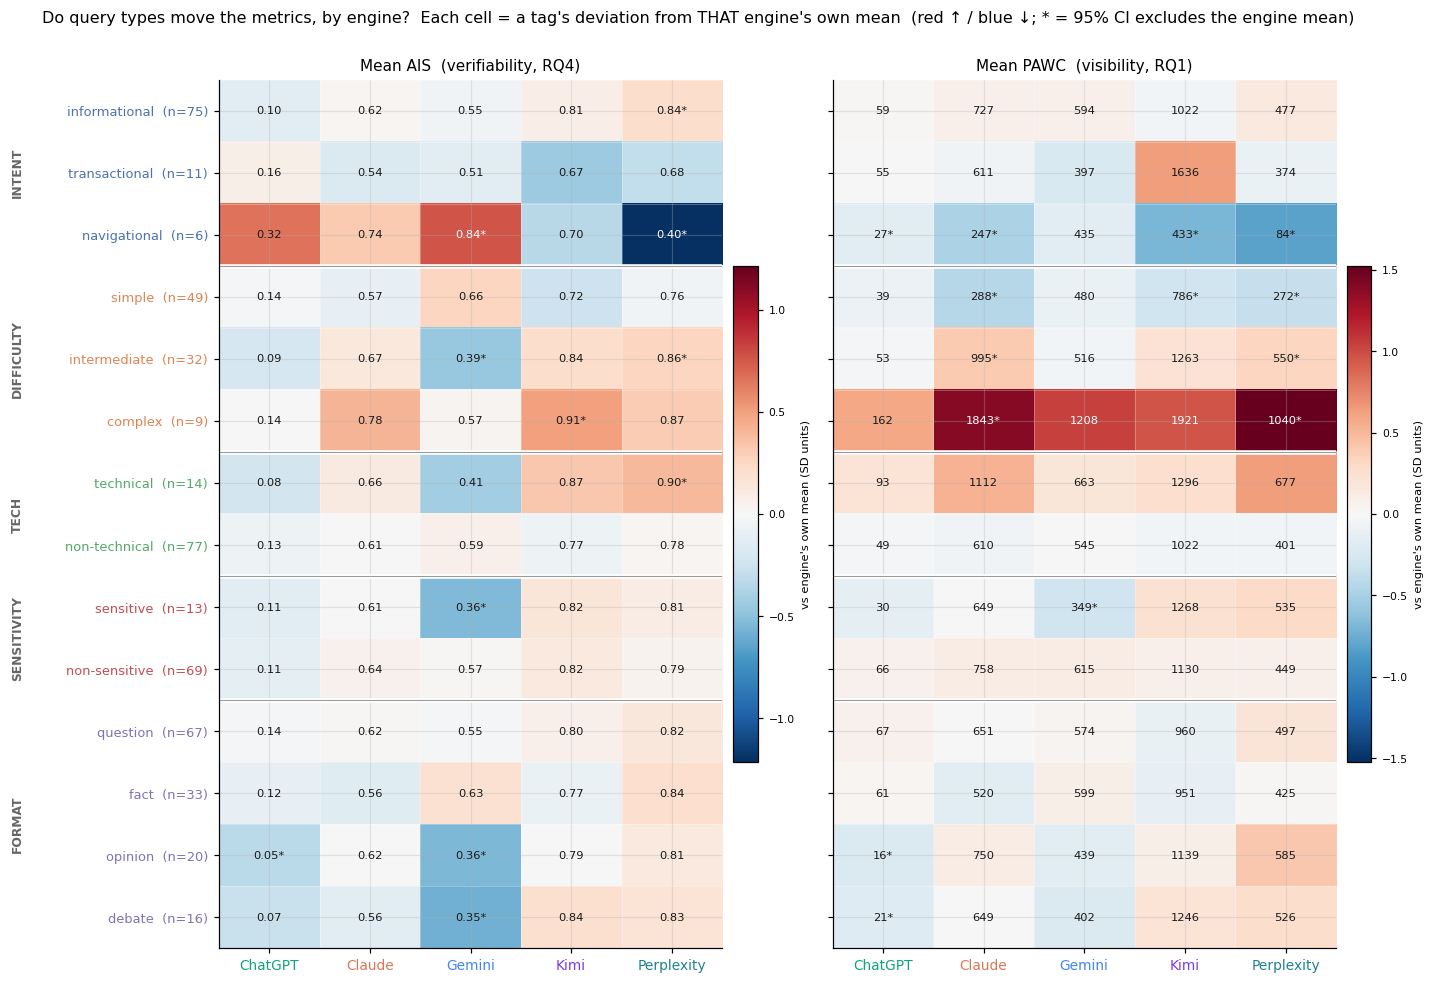

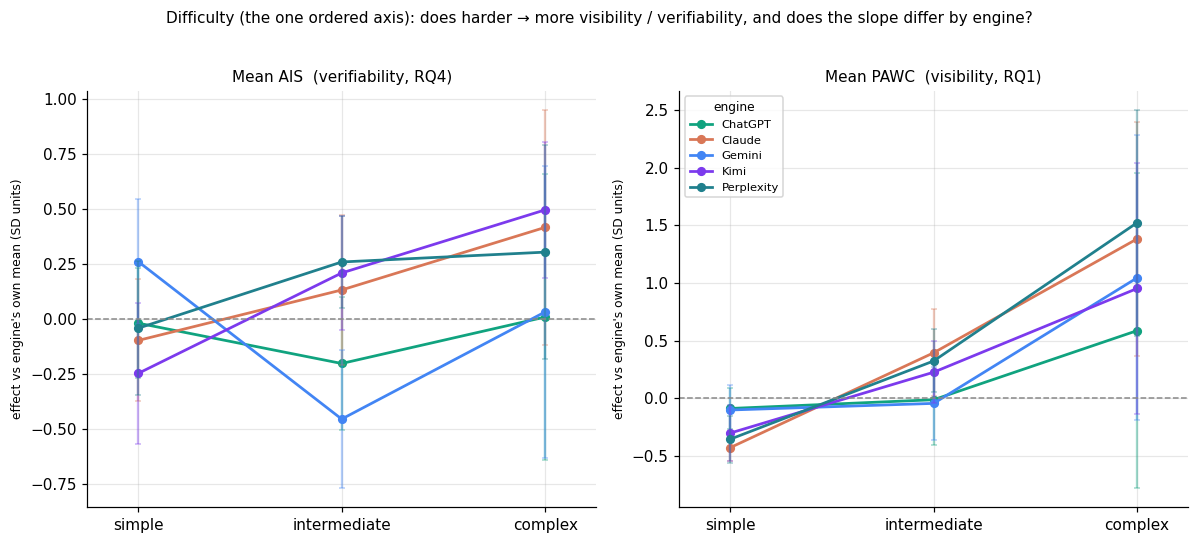

In [19]:
# Do query types move the metrics, BY ENGINE?  Engines sit on very different absolute scales (ChatGPT
# floored, Claude/Kimi high), so absolute effect plots conflate "does the tag move the metric" with
# "how high is this engine overall". Here every engine is normalised to its OWN baseline, so colour /
# height encode MOVEMENT and engines become directly comparable. Honest unit = the query (k=3 repeats
# collapsed to per-query means first), same as the pooled cell f84c175b. Reuses eligible_tags / AXES /
# AXIS_COLORS / ylabels / ycolors from above.  Two views: (A) within-engine effect heatmap over every
# tag x engine; (B) a slope plot for difficulty, the one genuinely ordered axis.
TAG_AXIS = {t: a for a, vs in AXES.items() for t in vs}
DIFF_ORDER = ["simple", "intermediate", "complex"]              # the only ordinal axis (Part B)

# Per-(tag, engine, query) means (collapse repeats), and each engine's own baseline distribution
# (mean + sd) taken across its per-query means -- the within-engine scale used to standardise.
qme = (tag_df[tag_df["tags"].isin(eligible_tags)]
          .groupby(["tags", "engine", "query_id"], observed=True)
          .agg(ais=("ais_rate", "mean"), pawc=("pawc_total", "mean")).reset_index())
eq = (df.groupby(["engine", "query_id"], observed=True)
        .agg(ais=("ais_rate", "mean"), pawc=("pawc_total", "mean")).reset_index())
base = eq.groupby("engine", observed=True).agg(
        ais_mean=("ais", "mean"), ais_sd=("ais", "std"),
        pawc_mean=("pawc", "mean"), pawc_sd=("pawc", "std"))

rows = []
for tag in ylabels:                                            # eligible tags, axis-grouped order
    for e in ENGINE_ORDER:
        sub = qme[(qme.tags == tag) & (qme.engine == e)]
        if not len(sub):
            continue
        rec = {"tag": tag, "axis": TAG_AXIS[tag], "engine": e, "n": len(sub)}
        for m in ("ais", "pawc"):
            tm, tse = sub[m].mean(), sub[m].sem()
            emean, esd = base.loc[e, f"{m}_mean"], base.loc[e, f"{m}_sd"]
            rec[f"{m}_mean"] = tm
            rec[f"{m}_sem"]  = tse
            rec[f"{m}_z"]    = (tm - emean) / esd if esd and not np.isnan(esd) else np.nan
            rec[f"{m}_sig"]  = bool(len(sub) > 1 and abs(tm - emean) > 1.96 * tse)   # CI excludes engine mean
        rows.append(rec)
EFF = pd.DataFrame(rows)

tags_ordered = ylabels
n_tags, n_eng = len(tags_ordered), len(ENGINE_ORDER)
n_per_tag = EFF.groupby("tag", observed=True).n.first()
row_labels = [f"{t}  (n={int(n_per_tag[t])})" for t in tags_ordered]
spans, k0 = [], 0                                              # contiguous axis spans (no gaps, for separators)
for k in range(1, n_tags + 1):
    if k == n_tags or TAG_AXIS[tags_ordered[k]] != TAG_AXIS[tags_ordered[k0]]:
        spans.append((TAG_AXIS[tags_ordered[k0]], k0, k - 1)); k0 = k
panels = [("ais", "Mean AIS  (verifiability, RQ4)", "{:.2f}"),
          ("pawc", "Mean PAWC  (visibility, RQ1)", "{:.0f}")]

# ---- Part A: within-engine effect heatmap (tags x engines), one panel per metric --------------------
figA, axesA = plt.subplots(1, 2, figsize=(13.5, max(7.0, 0.55 * n_tags + 1.2)), sharey=True)
for ax, (metric, title, fmt) in zip(axesA, panels):
    Z = np.full((n_tags, n_eng), np.nan)
    for i, tag in enumerate(tags_ordered):
        for j, e in enumerate(ENGINE_ORDER):
            r = EFF[(EFF.tag == tag) & (EFF.engine == e)]
            if len(r):
                Z[i, j] = r.iloc[0][f"{metric}_z"]
    vmax = np.nanmax(np.abs(Z)); vmax = min(2.5, vmax) if np.isfinite(vmax) and vmax > 0 else 1.0
    im = ax.imshow(Z, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    for i, tag in enumerate(tags_ordered):                      # annotate: absolute mean + '*' if sig
        for j, e in enumerate(ENGINE_ORDER):
            r = EFF[(EFF.tag == tag) & (EFF.engine == e)]
            if not len(r):
                continue
            r = r.iloc[0]; zz = Z[i, j]
            tc = "white" if (np.isfinite(zz) and abs(zz) > 0.62 * vmax) else "#1a1a1a"
            ax.text(j, i, fmt.format(r[f"{metric}_mean"]) + ("*" if r[f"{metric}_sig"] else ""),
                    ha="center", va="center", fontsize=7.5, color=tc)
    for _, _, hi in spans[:-1]:                                 # white gap lines between axes
        ax.axhline(hi + 0.5, color="white", lw=3); ax.axhline(hi + 0.5, color="#9a9a9a", lw=0.7)
    ax.set_xticks(range(n_eng)); ax.set_xticklabels([DISPLAY_NAME[e] for e in ENGINE_ORDER], fontsize=9)
    for tl, e in zip(ax.get_xticklabels(), ENGINE_ORDER):
        tl.set_color(ENGINE_COLORS[e])
    ax.set_yticks(range(n_tags)); ax.set_yticklabels(row_labels, fontsize=8.5)
    for tl, t in zip(ax.get_yticklabels(), tags_ordered):
        tl.set_color(AXIS_COLORS[TAG_AXIS[t]])
    ax.set_xticks(np.arange(-.5, n_eng, 1), minor=True); ax.set_yticks(np.arange(-.5, n_tags, 1), minor=True)
    ax.grid(which="minor", color="white", lw=0.6); ax.tick_params(which="minor", length=0)
    ax.set_title(title, fontsize=10)
    cb = figA.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cb.ax.tick_params(labelsize=7); cb.set_label("vs engine's own mean (SD units)", fontsize=7.5)
for axis, lo_i, hi_i in spans:                                 # axis-group labels far left
    axesA[0].text(-0.40, (lo_i + hi_i) / 2, axis.upper(), transform=axesA[0].get_yaxis_transform(),
                  rotation=90, va="center", ha="center", fontsize=8, fontweight="bold", color="#666666")
figA.suptitle("Do query types move the metrics, by engine?  Each cell = a tag's deviation from THAT "
              "engine's own mean  (red ↑ / blue ↓; * = 95% CI excludes the engine mean)", y=1.0, fontsize=10.5)
figA.tight_layout(rect=[0.03, 0, 1, 1])
plt.show()

# ---- Part B: difficulty slope (the one ordered axis), same within-engine effect on a shared y --------
figB, axesB = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True)
xpos = np.arange(len(DIFF_ORDER))
for ax, (metric, title, _) in zip(axesB, panels):
    for e in ENGINE_ORDER:
        ys, err = [], []
        for tag in DIFF_ORDER:
            r = EFF[(EFF.tag == tag) & (EFF.engine == e)]
            esd = base.loc[e, f"{metric}_sd"]
            if len(r) and esd:
                r = r.iloc[0]; ys.append(r[f"{metric}_z"]); err.append(1.96 * r[f"{metric}_sem"] / esd)
            else:
                ys.append(np.nan); err.append(np.nan)
        ax.plot(xpos, ys, "-o", color=ENGINE_COLORS[e], lw=1.8, ms=5, label=DISPLAY_NAME[e])
        ax.errorbar(xpos, ys, yerr=err, fmt="none", ecolor=ENGINE_COLORS[e], alpha=0.4, capsize=2)
    ax.axhline(0, color="#888888", ls="--", lw=1)
    ax.set_xticks(xpos); ax.set_xticklabels(DIFF_ORDER); ax.set_xlim(-0.25, len(DIFF_ORDER) - 0.75)
    ax.set_title(title, fontsize=10); ax.set_ylabel("effect vs engine's own mean (SD units)", fontsize=8)
axesB[1].legend(fontsize=7.5, loc="best", title="engine", title_fontsize=8)
figB.suptitle("Difficulty (the one ordered axis): does harder → more visibility / verifiability, "
              "and does the slope differ by engine?", y=1.02, fontsize=10)
figB.tight_layout()
plt.show()

domain-tag coverage over 100 queries: 10 none | 87 one | 3 multi   (multi-domain queries are counted under each of their domains)

31 domains total; 7 well-populated (>= 4 queries), 24 low-n.
Well-populated GEO-Bench domains (pooled over engines × repeats):


,n_queries,n_rows,mean_ais,mean_pawc,mean_cited
domain,,,,,
arts and entertainment,14,210,0.61,390.37,5.32
science,11,165,0.60,608.33,6.32
health,9,135,0.69,754.87,5.95
food and drink,7,105,0.49,428.54,5.27
computers and electronics,5,75,0.60,861.22,5.68
history,4,60,0.61,894.97,8.22
people and society,4,60,0.55,855.59,4.72


24 further domains carry fewer than 4 queries each and are not reported here; their means are too noisy for pilot-level conclusions.


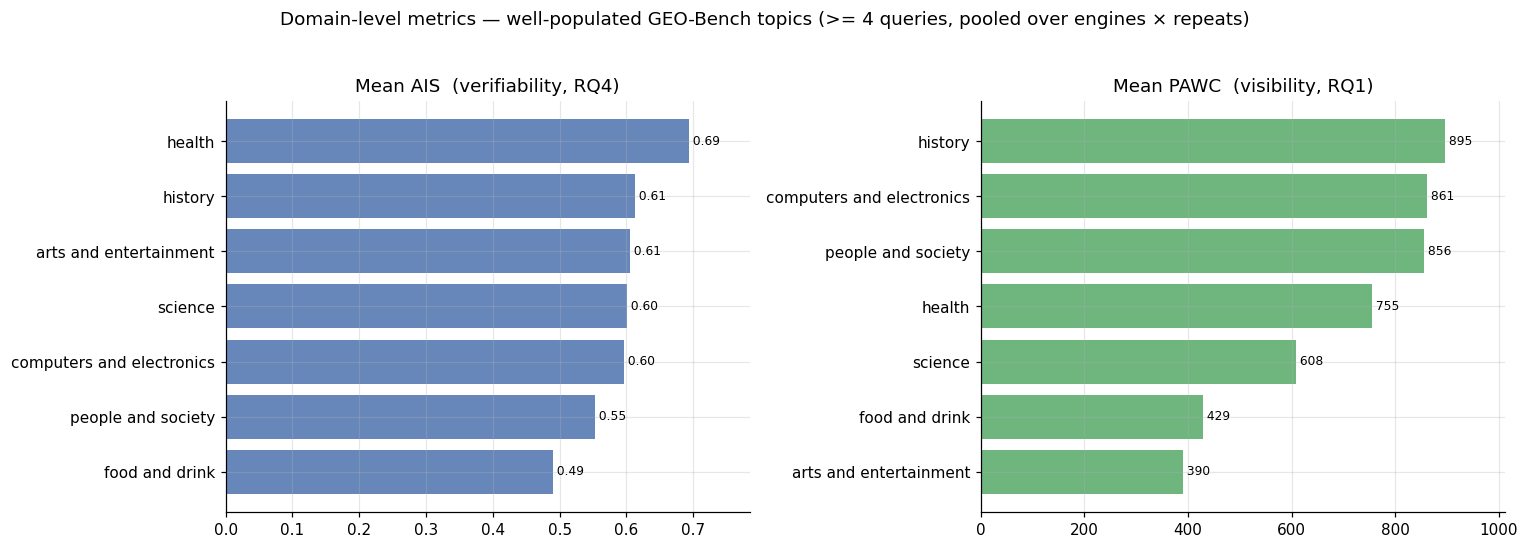

In [20]:
# Domain-level breakdown of the two research metrics across the GEO-Bench *topic* tags.
# `tags` is multi-label and mixes facets, so isolate the subject-matter DOMAINS with an explicit
# allow-list. Multi-domain queries count under each of their domains; queries with no domain tag
# fall out. The TABLE and CHART report only well-populated domains (>= MIN_QUERIES); low-n domains
# are summarised in one sentence so single-query topics can't mislead the eye.
DOMAINS = [
    "arts and entertainment", "science", "health", "food and drink",
    "computers and electronics", "history", "people and society",
    "business and industrial", "finance", "jobs and education", "politics",
    "biology", "books and literature", "entertainment", "physics", "sports",
    "technology", "travel", "automotive", "engineering", "environment", "games",
    "geography", "internet and telecom", "language", "law", "law and government",
    "military", "pets and animals", "philosophy", "religion",
]
MIN_QUERIES = 4
_DOMSET = set(DOMAINS)

dom = df.explode("tags")
dom = dom[dom["tags"].astype(str).str.strip().str.lower().isin(_DOMSET)].copy()
dom["domain"] = dom["tags"].astype(str).str.strip().str.lower()

_ndom = (df.drop_duplicates("query_id")["tags"]
           .apply(lambda ts: sum(str(t).strip().lower() in _DOMSET for t in ts)))
print(f"domain-tag coverage over {len(_ndom)} queries: "
      f"{(_ndom == 0).sum()} none | {(_ndom == 1).sum()} one | {(_ndom > 1).sum()} multi   "
      f"(multi-domain queries are counted under each of their domains)")

domain_tbl = (dom.groupby("domain", observed=True)
                 .agg(n_queries=("query_id", "nunique"),
                      n_rows=("query_id", "size"),
                      mean_ais=("ais_rate", "mean"),
                      mean_pawc=("pawc_total", "mean"),
                      mean_cited=("n_sources_cited", "mean"))
                 .sort_values("n_queries", ascending=False))
domain_tbl["low_n"] = domain_tbl["n_queries"] < MIN_QUERIES
well = domain_tbl[~domain_tbl.low_n]

print(f"\n{len(domain_tbl)} domains total; {(~domain_tbl.low_n).sum()} well-populated "
      f"(>= {MIN_QUERIES} queries), {domain_tbl.low_n.sum()} low-n.")
print("Well-populated GEO-Bench domains (pooled over engines × repeats):")
display(well.drop(columns="low_n").round(2))
print(f"{domain_tbl.low_n.sum()} further domains carry fewer than {MIN_QUERIES} queries each and are "
      "not reported here; their means are too noisy for pilot-level conclusions.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, m, title, col in [(axes[0], "mean_ais",  "Mean AIS  (verifiability, RQ4)", "#4c72b0"),
                          (axes[1], "mean_pawc", "Mean PAWC  (visibility, RQ1)",   "#55a868")]:
    s = well[m].sort_values()
    ax.barh(s.index, s.values, color=col, alpha=0.85)
    for yy, v in enumerate(s.values):
        ax.text(v, yy, f" {v:.2f}" if m == "mean_ais" else f" {v:.0f}",
                va="center", ha="left", fontsize=8)
    ax.set_title(title); ax.margins(x=0.13)
fig.suptitle(f"Domain-level metrics — well-populated GEO-Bench topics "
             f"(>= {MIN_QUERIES} queries, pooled over engines × repeats)", y=1.03)
fig.tight_layout()
plt.show()

per (domain x engine) cell: 4-14 queries; k=3 repeats collapsed to per-query means first, then 95% CI across queries (as in the tag-axis cell).


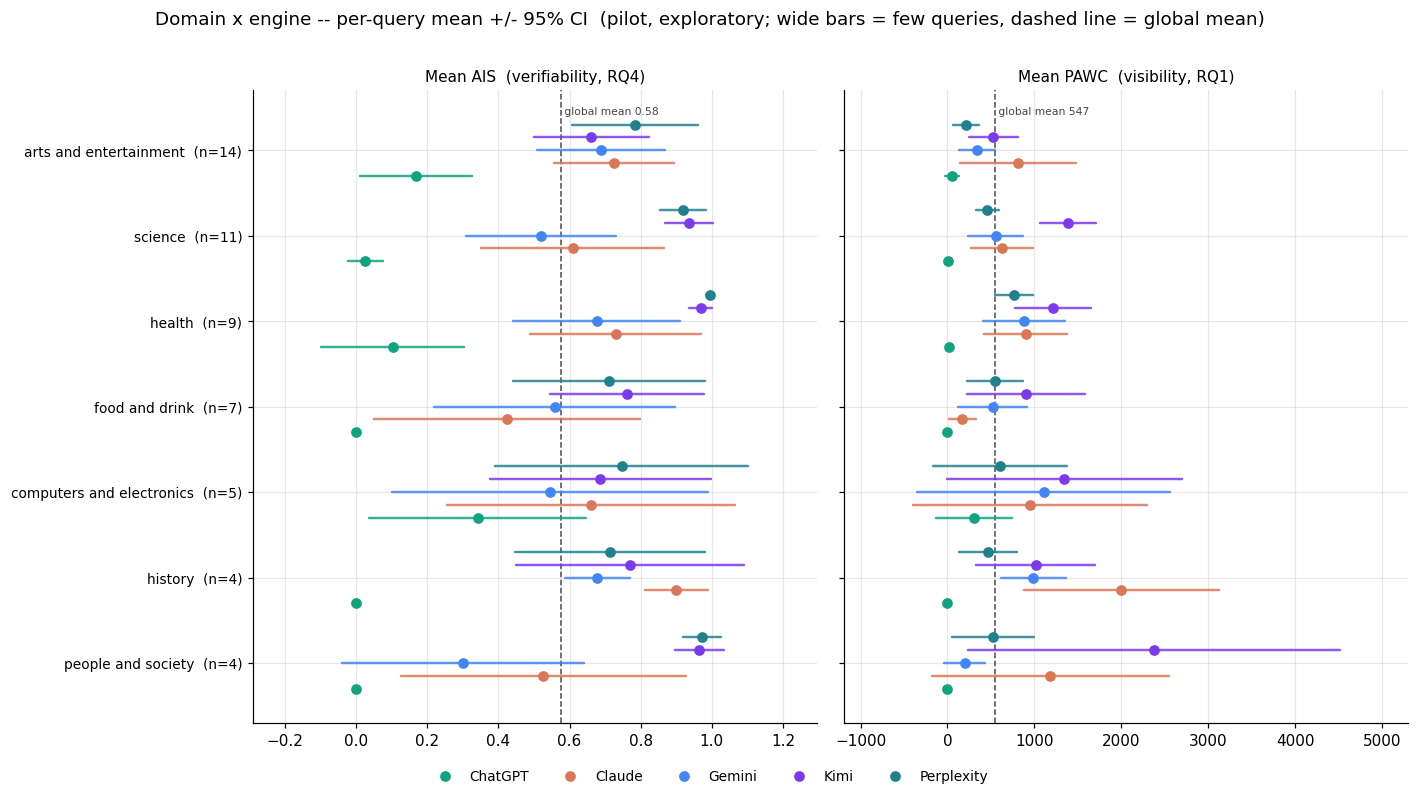

In [21]:
# Swap of the per-engine domain breakdown: a DODGED CLEVELAND DOT PLOT with 95% CIs.
# Honest unit = the QUERY (same idiom as the tag-axis effect plot, cell f84c175b): collapse the k=3
# repeats to a per-query mean first, then mean +/- 1.96*SEM ACROSS the 4-14 queries in each
# (domain x engine) cell -- so small-n noise shows as WIDE whiskers, not false precision.
# Reuses `dom`, `well`, ENGINE_ORDER / ENGINE_COLORS / DISPLAY_NAME from earlier cells.
DOMS = well.sort_values("n_queries", ascending=False).index.tolist()   # most-populated domains on top
DNQ  = well["n_queries"].to_dict()

# (i) collapse k=3 repeats -> one value per (domain, engine, query); (ii) mean +/- 95% CI across queries
qcell = (dom[dom.domain.isin(DOMS)]
           .groupby(["domain", "engine", "query_id"], observed=True)
           .agg(ais=("ais_rate", "mean"), pawc=("pawc_total", "mean"))
           .reset_index())
stat = (qcell.groupby(["domain", "engine"], observed=True)
             .agg(ais_mean=("ais", "mean"), ais_se=("ais", "sem"),
                  pawc_mean=("pawc", "mean"), pawc_se=("pawc", "sem")))
for met in ("ais", "pawc"):
    stat[f"{met}_lo"] = stat[f"{met}_mean"] - 1.96 * stat[f"{met}_se"]
    stat[f"{met}_hi"] = stat[f"{met}_mean"] + 1.96 * stat[f"{met}_se"]

print(f"per (domain x engine) cell: {min(DNQ.values())}-{max(DNQ.values())} queries; k={cfg.K} repeats "
      f"collapsed to per-query means first, then 95% CI across queries (as in the tag-axis cell).")

# y-layout: one band per domain (sharey), the five engines dodged within each band
ybase = {d: i for i, d in enumerate(DOMS)}
dodge = dict(zip(ENGINE_ORDER, np.linspace(0.30, -0.30, len(ENGINE_ORDER))))

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
panels = [("ais",  "Mean AIS  (verifiability, RQ4)", df.ais_rate.mean(),  ".2f"),
          ("pawc", "Mean PAWC  (visibility, RQ1)",   df.pawc_total.mean(), ".0f")]
for ax, (met, title, gmean, fmt) in zip(axes, panels):
    ax.axvline(gmean, color="black", ls="--", lw=1, alpha=0.7)
    ax.text(gmean, -0.45, f" global mean {gmean:{fmt}}", fontsize=7, color="#444444", va="center")
    for (d, e), r in stat.iterrows():
        yy = ybase[d] + dodge[e]
        lo, hi, mn = r[f"{met}_lo"], r[f"{met}_hi"], r[f"{met}_mean"]
        if np.isfinite(lo) and np.isfinite(hi):
            ax.plot([lo, hi], [yy, yy], color=ENGINE_COLORS[e], lw=1.6,
                    alpha=0.85, solid_capstyle="round")
        ax.plot(mn, yy, "o", color=ENGINE_COLORS[e], ms=6, zorder=3)
    ax.set_yticks(range(len(DOMS)))
    ax.set_yticklabels([f"{d}  (n={DNQ[d]})" for d in DOMS], fontsize=9)
    ax.set_ylim(-0.7, len(DOMS) - 0.3); ax.invert_yaxis()
    ax.set_title(title, fontsize=10); ax.margins(x=0.16)
handles = [plt.Line2D([0], [0], marker="o", color=ENGINE_COLORS[e], lw=0,
                      label=DISPLAY_NAME[e]) for e in ENGINE_ORDER]
fig.legend(handles=handles, ncol=len(ENGINE_ORDER), loc="lower center",
           bbox_to_anchor=(0.5, -0.01), fontsize=9, frameon=False)
fig.suptitle("Domain x engine -- per-query mean +/- 95% CI  (pilot, exploratory; "
             "wide bars = few queries, dashed line = global mean)", y=1.01)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

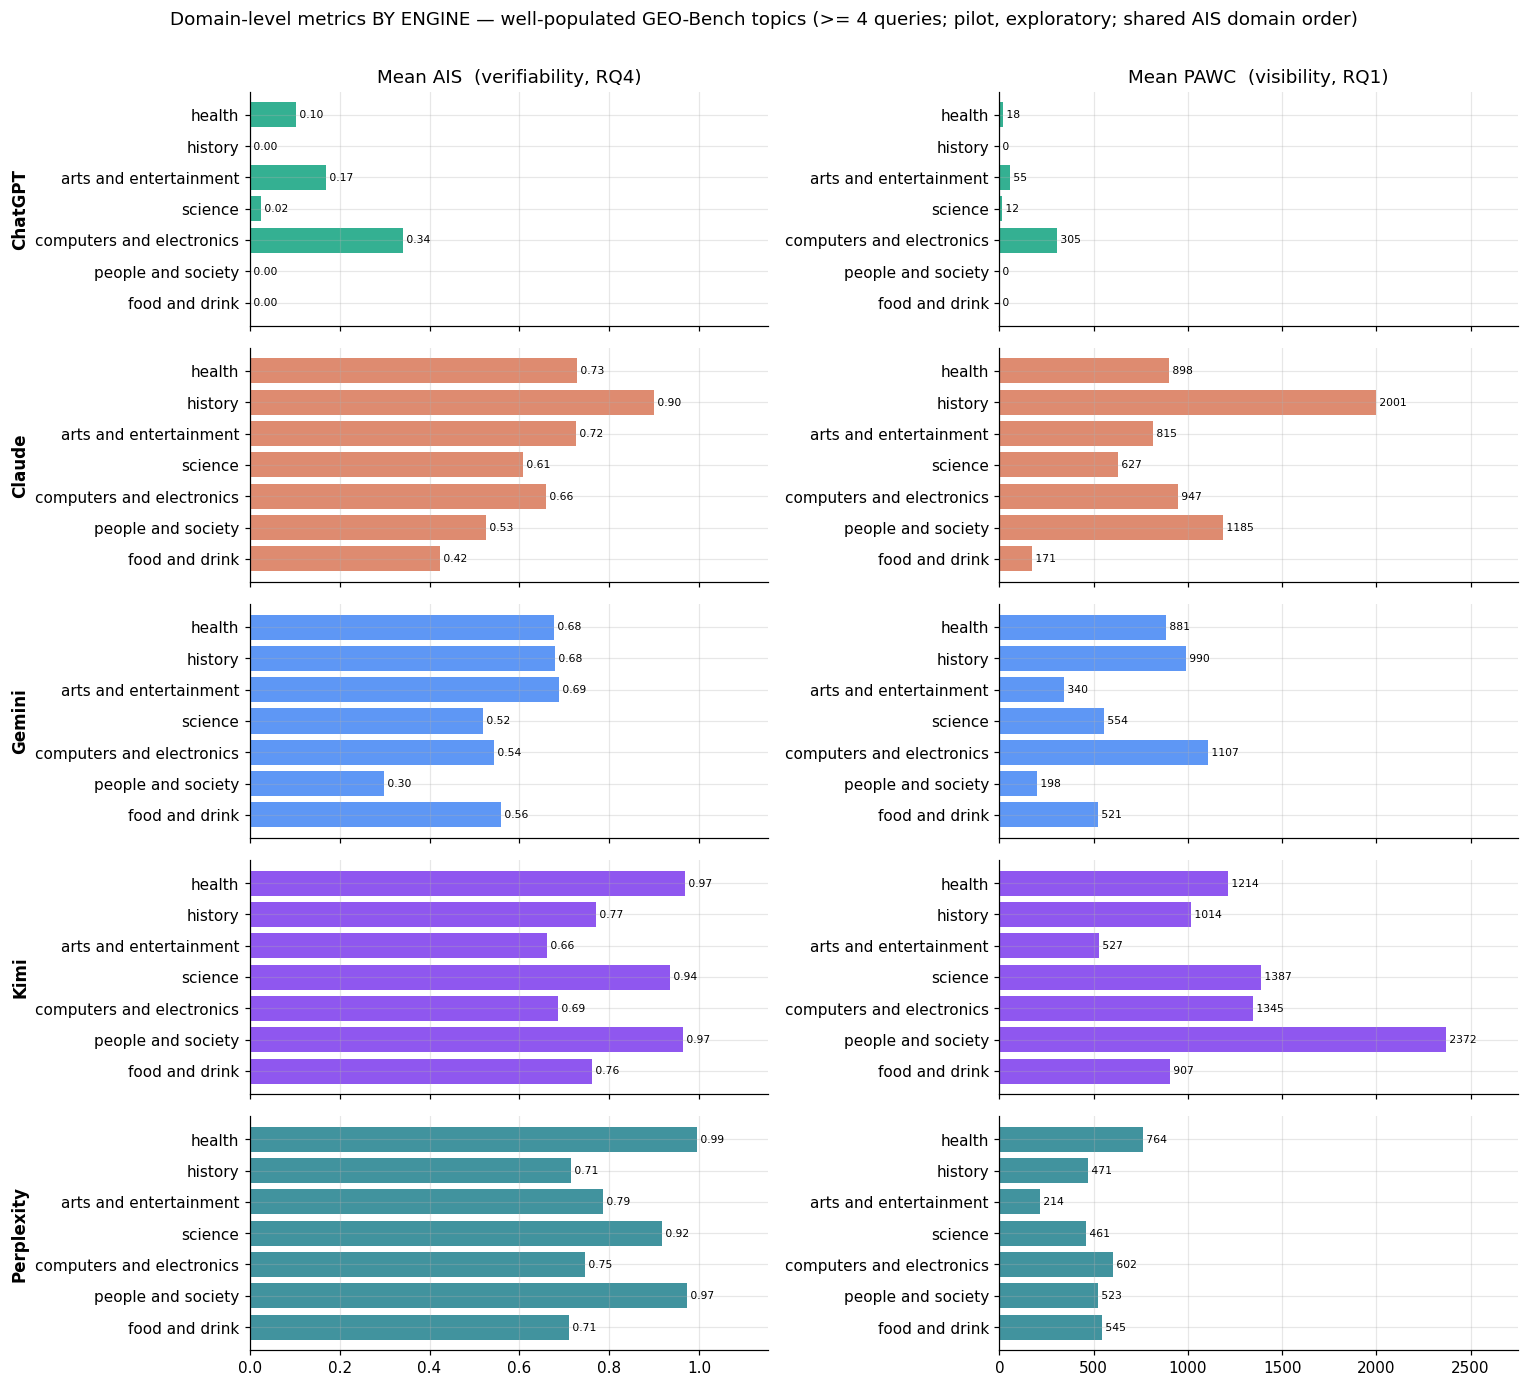

In [22]:
# Domain breakdown SPLIT BY LLM as SMALL MULTIPLES (one panel-row per engine) -- companion view to the
# dot-plot above. Reuses `dom`, `well`, MIN_QUERIES and the ENGINE_* conventions from earlier cells.
# Both columns share ONE domain order (the pooled-AIS order via `order`), so each engine row's AIS and
# PAWC panels are stacked identically (health lines up with health, etc.) for direct left<->right reading.
# CAVEAT (exploratory): each (domain x engine) cell holds only 4-14 queries x k=3 repeats -> pilot-noisy.
de = (dom[dom.domain.isin(well.index)]
        .groupby(["domain", "engine"], observed=True)
        .agg(mean_ais=("ais_rate", "mean"), mean_pawc=("pawc_total", "mean")))
order = well["mean_ais"].sort_values().index.tolist()   # single shared order for BOTH panels
metrics = [("mean_ais",  "Mean AIS  (verifiability, RQ4)", ".2f"),
           ("mean_pawc", "Mean PAWC  (visibility, RQ1)",   ".0f")]

fig, axes = plt.subplots(len(ENGINE_ORDER), 2, figsize=(14, 2.5 * len(ENGINE_ORDER)), sharex="col")
for r, eng in enumerate(ENGINE_ORDER):
    sub_e = de.xs(eng, level="engine")
    for c, (m, title, fmt) in enumerate(metrics):
        ax = axes[r, c]
        s = sub_e[m].reindex(order)             # SAME domain order on both AIS and PAWC
        ax.barh(s.index, s.values, color=ENGINE_COLORS[eng], alpha=0.85)
        for yy, v in enumerate(s.values):
            if np.isfinite(v):
                ax.text(v, yy, f" {v:{fmt}}", va="center", ha="left", fontsize=7)
        ax.margins(x=0.16)
        if r == 0:
            ax.set_title(title)
    axes[r, 0].set_ylabel(DISPLAY_NAME[eng], fontsize=11, fontweight="bold")
fig.suptitle(f"Domain-level metrics BY ENGINE — well-populated GEO-Bench topics "
             f"(>= {MIN_QUERIES} queries; pilot, exploratory; shared AIS domain order)", y=1.005)
fig.tight_layout()
plt.show()

Per-engine domain breakdowns are shown above **for the pilot only, as exploratory** — the per-cell sample sizes (4–14 queries per domain × engine) are too small for firm per-engine conclusions, so the fuller domain × engine heatmaps (as in the V1 notebook) remain **deferred to the scale-up**. Complex queries are the only consistent tag-level mover on the difficulty axis, drawing
longer, more-cited, better-supported answers (AIS 0.66 vs the 0.58 global-mean baseline). Two further
patterns are worth noting. First, on the format axis, opinion (AIS 0.53) and debate (0.53) sit below
the global mean of 0.58 — these are query types where verifiability is structurally harder, since the
source material being cited may not directly support a claim that is itself an evaluative judgement.
Second, navigational queries show the cleanest illustration that PAWC and AIS measure different
things: their PAWC is unusually low (~245 vs ~600 elsewhere) but their AIS is roughly normal (0.60).
Engines correctly cite a single URL and produce a short answer — verifiable, but not visibility-heavy.
The hardest-query table reinforces this: meta-questions about AI itself, creative tasks, bare URLs,
debate prompts, and transactional requests dominate the bottom of the leaderboard, none of which are
"hard" in a topical-difficulty sense — they are formats that the AIS denominator is not designed to
score.

## 9 · PAWC position structure

`pawc_by_source_position` records, per response, how much position-weighted *supported* word-mass
each cited source contributed (keyed by the source's rank in the answer). Averaging across responses
shows where supported content actually sits — the empirical motivation for weighting earlier
positions more heavily (Aggarwal et al. 2024, linear decay, α = 0.5).

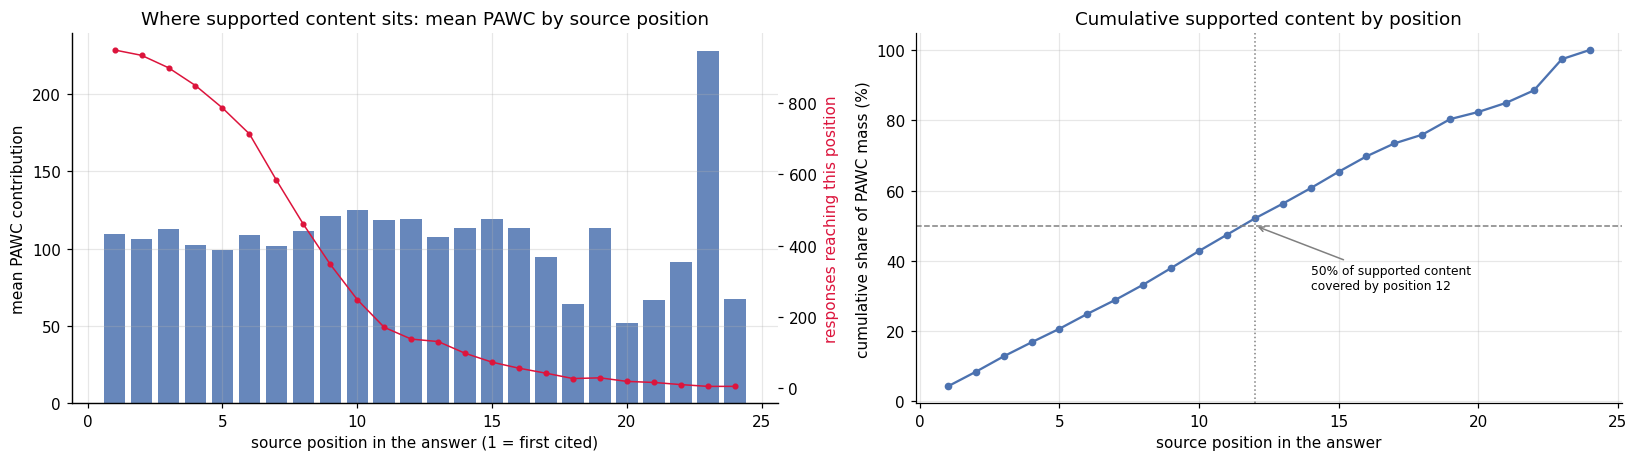

first-5-position share of total PAWC mass: 20.7%
position at which 50% of PAWC mass is covered: 12


In [23]:
pos = pd.json_normalize(df["pawc_by_source_position"])
pos.columns = pos.columns.astype(int)
pos = pos.reindex(sorted(pos.columns), axis=1)

mean_by_pos = pos.mean()           # mean over responses where that position was present
present     = pos.notna().sum()    # how many responses reached each position
cum_share   = mean_by_pos.cumsum() / mean_by_pos.sum() * 100
cross50     = int(cum_share[cum_share >= 50].index[0])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 4.3))

# Panel A — mean PAWC by source position, with a secondary axis for coverage.
axA.bar(mean_by_pos.index, mean_by_pos.values, color="#4c72b0", alpha=0.85)
axA.set_xlabel("source position in the answer (1 = first cited)")
axA.set_ylabel("mean PAWC contribution")
axA.set_title("Where supported content sits: mean PAWC by source position")
axA2 = axA.twinx()
axA2.plot(present.index, present.values, color="crimson", marker=".", lw=1)
axA2.set_ylabel("responses reaching this position", color="crimson")
axA2.grid(False)

# Panel B — cumulative PAWC share by position.
axB.plot(cum_share.index, cum_share.values, color="#4c72b0", marker="o", ms=4)
axB.axhline(50, color="grey", ls="--", lw=1)
axB.axvline(cross50, color="grey", ls=":", lw=1)
axB.annotate(f"50% of supported content\ncovered by position {cross50}",
             xy=(cross50, 50), xytext=(cross50 + 2, 32), fontsize=8,
             arrowprops=dict(arrowstyle="->", color="grey"))
axB.set_xlabel("source position in the answer")
axB.set_ylabel("cumulative share of PAWC mass (%)")
axB.set_title("Cumulative supported content by position")
fig.tight_layout()
plt.show()

print(f"first-5-position share of total PAWC mass: {mean_by_pos.loc[:5].sum()/mean_by_pos.sum()*100:.1f}%")
print(f"position at which 50% of PAWC mass is covered: {cross50}")

## 10 · Source authority — what *kinds* of sources each engine cites

§5–§9 measure *how much* each engine cites and *how faithfully* it grounds those citations (PAWC, AIS). This section asks a different question: **what kind of sources does each engine reach for?** Two engines can post an identical AIS while drawing on very different evidence — peer-reviewed papers versus YouTube and Reddit.

Every cited domain in `citations_pilot.parquet` is mapped to one of **ten authority tiers** by a transparent, rule-based classifier (registrable-domain matching, spelled out in the next cell so it is auditable and editable). The view is **conditional on the engine citing**: the per-engine denominator is the number of queries where that engine returned ≥ 1 source (ChatGPT 32, Claude 78, Gemini 82, Kimi 99, Perplexity 100) — the same conditional gate as §5. Two complementary views are shown. The **donut charts** give each engine's *citation mix* — the share of **all** its citations by tier, with the raw citation count at the centre (ChatGPT 243, Claude 1,477, Gemini 2,105, Kimi 2,798, Perplexity 2,134 distinct cited sources). The **dot plot** shows the same composition as a *per-query* mean ± **95% CI across queries** (the honest unit for uncertainty, as in §8); the two differ only slightly, most for ChatGPT whose per-query mean rests on just 32 cited queries.

This is **pilot, exploratory** — per-engine samples are small (ChatGPT especially), so the figures show wide intervals rather than false precision; the scale-up (250 × k = 8) will firm them up. The taxonomy is deliberately conservative: the residual tier `Commercial / other` absorbs the long tail of independent and commercial sites the curated lists cannot resolve (2,500+ domains) — a **residual, not a quality verdict**; four functional clusters (health/medical, tech/software, reference/education, org/NGO) are carved out of it where they form recognisable groups.

In [24]:
# Map every cited domain to one of TEN AUTHORITY TIERS. Keys are REGISTRABLE domains, matched on a
# label boundary (d == k or d.endswith("."+k)) -- never raw substrings, else "microsoft.com" would
# match "ft.com" (Financial Times). Precedence = list order below (most authoritative first); the old
# "Other" bucket is now resolved into four functional clusters -- Tech/software, Health/medical,
# Reference/education, Org/NGO -- with a `Commercial / other` long-tail residual.
cit = pd.read_parquet(cfg.SILVER / "citations_pilot.parquet")
cit = cit[cit.engine.isin(ENGINE_ORDER)].copy()

TIERS = ["Gov / Edu", "Academic", "Encyclopedic", "News / media", "Tech / software",
         "Health / medical", "Reference / education", "Org / NGO / think-tank",
         "UGC / social", "Commercial / other"]
ACADEMIC = ("ncbi.nlm.nih.gov", "arxiv.org", "doi.org", "nature.com", "science.org", "sciencedirect.com",
            "springer.com", "springeropen.com", "wiley.com", "tandfonline.com", "jstor.org",
            "researchgate.net", "ssrn.com", "biorxiv.org", "medrxiv.org", "plos.org", "frontiersin.org",
            "mdpi.com", "ieee.org", "acm.org", "semanticscholar.org", "cell.com", "bmj.com",
            "thelancet.com", "nejm.org", "pnas.org", "sagepub.com", "cambridge.org", "oup.com",
            "annualreviews.org", "aps.org", "rsc.org", "iop.org", "jamanetwork.com")
ENCYCLOPEDIC = ("wikipedia.org", "wikimedia.org", "wiktionary.org", "wikisource.org", "wikibooks.org",
                "britannica.com", "merriam-webster.com", "scholarpedia.org")
NEWS = ("nytimes.com", "washingtonpost.com", "wsj.com", "bbc.co.uk", "bbc.com", "reuters.com",
        "apnews.com", "theguardian.com", "guardian.co.uk", "cnn.com", "nbcnews.com", "abcnews.go.com",
        "cbsnews.com", "npr.org", "bloomberg.com", "forbes.com", "economist.com", "ft.com", "time.com",
        "theatlantic.com", "vox.com", "axios.com", "politico.com", "aljazeera.com", "dw.com", "cnbc.com",
        "businessinsider.com", "usatoday.com", "latimes.com", "newyorker.com", "telegraph.co.uk",
        "scientificamerican.com", "nationalgeographic.com", "techcrunch.com", "theverge.com", "wired.com",
        "arstechnica.com", "engadget.com")
TECH = ("python.org", "microsoft.com", "mozilla.org", "w3schools.com", "geeksforgeeks.org",
        "freecodecamp.org", "techradar.com", "pcmag.com", "tomshardware.com", "cnet.com", "zdnet.com",
        "digitaltrends.com", "howtogeek.com", "makeuseof.com", "kubernetes.io", "docker.com", "oracle.com",
        "ibm.com", "redhat.com", "gsmarena.com", "androidauthority.com", "9to5mac.com", "macrumors.com",
        "lifewire.com", "stackoverflow.blog")
HEALTH = ("clevelandclinic.org", "webmd.com", "healthline.com", "mayoclinic.org", "medicalnewstoday.com",
          "psychologytoday.com", "verywellhealth.com", "verywellmind.com", "drugs.com", "everydayhealth.com",
          "medicinenet.com", "health.com", "goodrx.com", "kidshealth.org", "hopkinsmedicine.org",
          "patient.info", "mommed.com", "medanta.org", "healthgrades.com")
REFEDU = ("dictionary.com", "thesaurus.com", "study.com", "cliffsnotes.com", "sparknotes.com",
          "coursehero.com", "khanacademy.org", "investopedia.com", "archive.org", "gutenberg.org",
          "biography.com", "thoughtco.com", "encyclopedia.com", "collinsdictionary.com", "vocabulary.com",
          "byjus.com", "toppr.com", "education.com")
ORG = ("un.org", "oecd.org", "imf.org", "wto.org", "weforum.org", "cato.org", "rand.org", "pewresearch.org",
       "oceanconservancy.org", "planetary.org", "learningpolicyinstitute.org", "redcross.org",
       "worldbank.org", "amnesty.org", "wwf.org", "who.int")
UGC = ("reddit.com", "youtube.com", "youtu.be", "quora.com", "twitter.com", "x.com", "facebook.com",
       "instagram.com", "tiktok.com", "stackexchange.com", "stackoverflow.com", "superuser.com",
       "serverfault.com", "askubuntu.com", "medium.com", "substack.com", "linkedin.com", "pinterest.com",
       "tumblr.com", "github.com", "github.io", "discord.com", "fandom.com", "wikihow.com")
GOV_EXTRA = ("canada.ca", "gc.ca", "nhs.uk", "europa.eu", "govt.nz", "gov.au")  # non-US gov/health

def _ends(d, keys):
    return any(d == k or d.endswith("." + k) for k in keys)

def classify_authority(domain):
    d = str(domain).lower().strip()
    if d.startswith("www."):
        d = d[4:]
    if _ends(d, ACADEMIC):
        return "Academic"
    if (d.endswith((".gov", ".mil", ".edu", ".int")) or ".gov." in d or ".edu." in d or ".ac." in d
            or ".gouv." in d or ".go.jp" in d or ".go.kr" in d or ".gob." in d or _ends(d, GOV_EXTRA)):
        return "Gov / Edu"
    if _ends(d, ENCYCLOPEDIC):
        return "Encyclopedic"
    if _ends(d, NEWS):
        return "News / media"
    if _ends(d, TECH):
        return "Tech / software"
    if _ends(d, HEALTH):
        return "Health / medical"
    if _ends(d, REFEDU):
        return "Reference / education"
    if _ends(d, ORG):
        return "Org / NGO / think-tank"
    if _ends(d, UGC):
        return "UGC / social"
    return "Commercial / other"

cit["tier"] = pd.Categorical(cit["domain"].map(classify_authority), categories=TIERS, ordered=True)

# Auditability: pooled tier mix + the most-cited domains in the four carved tiers and the residual,
# so the breakdown is inspectable (the long tail is 2,500+ domains, so the carved tiers undercount and
# `Commercial / other` is an upper bound -- a residual, not a quality verdict).
pooled = (cit.tier.value_counts(normalize=True).reindex(TIERS) * 100).round(1)
print(f"{len(cit):,} citations across {cit.engine.nunique()} engines | pooled tier shares (%):")
print(pooled.to_string())
print("\nTop domains in the carved-out tiers + residual (audit the breakdown):")
for t in ["Tech / software", "Health / medical", "Reference / education",
          "Org / NGO / think-tank", "Commercial / other"]:
    top = cit.loc[cit.tier == t, "domain"].value_counts().head(6)
    print(f"  {t:23s} " + "  ".join(f"{d} ({n})" for d, n in top.items()))

8,764 citations across 5 engines | pooled tier shares (%):
tier
Gov / Edu                 10.2
Academic                   4.7
Encyclopedic               4.9
News / media               1.4
Tech / software            2.2
Health / medical           2.3
Reference / education      1.1
Org / NGO / think-tank     1.0
UGC / social               9.1
Commercial / other        63.0

Top domains in the carved-out tiers + residual (audit the breakdown):
  Tech / software         www.python.org (38)  learn.microsoft.com (26)  support.microsoft.com (20)  www.techradar.com (11)  pcmag.com (11)  www.tomshardware.com (10)
  Health / medical        my.clevelandclinic.org (34)  www.webmd.com (25)  www.healthline.com (22)  mommed.com (21)  www.mayoclinic.org (16)  www.medicalnewstoday.com (16)
  Reference / education   www.dictionary.com (16)  archive.org (14)  study.com (10)  www.cliffsnotes.com (9)  www.vocabulary.com (9)  www.collinsdictionary.com (8)
  Org / NGO / think-tank  learningpolicyinstitute.or

In [25]:
# Composition CONDITIONAL ON CITING. For each (engine, query, repeat) cell with >=1 cited source, take
# the share of DISTINCT sources falling in each tier; collapse the k=3 repeats to a per-query mean;
# then mean +/- 95% CI ACROSS queries -- the honest unit (cell f84c175b). Filling absent tiers with 0
# per cell keeps each engine's per-query shares on a complete simplex (columns sum to 1, shared CI
# denominator = the queries that engine actually cited in: 32 / 78 / 82 / 99 / 100).
_cell = (cit.drop_duplicates(["engine", "query_id", "run_index", "url_canonical"])
            .groupby(["engine", "query_id", "run_index", "tier"], observed=True)
            .size().rename("k").reset_index())
_cell["share"] = _cell["k"] / _cell.groupby(["engine", "query_id", "run_index"],
                                            observed=True)["k"].transform("sum")
_full = (_cell[["engine", "query_id", "run_index"]].drop_duplicates()
            .merge(pd.DataFrame({"tier": TIERS}), how="cross")
            .merge(_cell[["engine", "query_id", "run_index", "tier", "share"]],
                   on=["engine", "query_id", "run_index", "tier"], how="left"))
_full["share"] = _full["share"].fillna(0.0)

perq = _full.groupby(["engine", "query_id", "tier"], observed=True)["share"].mean().reset_index()
auth = perq.groupby(["engine", "tier"], observed=True)["share"].agg(["mean", "sem"])
auth["lo"], auth["hi"] = auth["mean"] - 1.96 * auth["sem"], auth["mean"] + 1.96 * auth["sem"]
nq = perq.groupby("engine", observed=True)["query_id"].nunique().reindex(ENGINE_ORDER)

comp = (auth["mean"].unstack("tier").reindex(ENGINE_ORDER)[TIERS] * 100).round(1)
comp.insert(0, "n_cited_q", nq.astype(int))
comp.index = [DISPLAY_NAME[e] for e in ENGINE_ORDER]
print("Authority-tier composition by engine  (% of cited sources, conditional on citing):")
print(comp.to_string())

# Two headline contrasts with 95% CIs: high-authority (gov+academic+encyclopedic) vs UGC/social.
def _share_ci(mask_tiers, label):
    s = (perq[perq.tier.isin(mask_tiers)]
         .groupby(["engine", "query_id"], observed=True)["share"].sum())
    g = s.groupby("engine", observed=True)
    m, se = g.mean(), g.sem()
    rows = {DISPLAY_NAME[e]: {f"{label} %": round(m[e] * 100, 1),
                             "95% CI": f"[{(m[e]-1.96*se[e])*100:.1f}, {(m[e]+1.96*se[e])*100:.1f}]"}
            for e in ENGINE_ORDER}
    return pd.DataFrame(rows).T

print("\nHigh-authority share (Gov/Edu + Academic + Encyclopedic):")
print(_share_ci(["Gov / Edu", "Academic", "Encyclopedic"], "high-auth").to_string())
print("\nUGC / social share (YouTube, Reddit, forums, blogs):")
print(_share_ci(["UGC / social"], "UGC").to_string())

Authority-tier composition by engine  (% of cited sources, conditional on citing):
tier        n_cited_q  Gov / Edu  Academic  Encyclopedic  News / media  Tech / software  Health / medical  Reference / education  Org / NGO / think-tank  UGC / social  Commercial / other
ChatGPT            32       18.1       5.7           4.4           5.5              7.3               2.4                    1.6                     2.2           1.6                51.2
Claude             78        9.0       4.3           6.9           2.0              1.8               3.2                    1.4                     1.9           6.4                63.1
Gemini             82       10.8       1.4           8.2           1.7              2.4               1.6                    0.6                     0.5          18.0                54.9
Kimi               99        9.5       5.8           0.8           0.9              3.4               2.2                    1.0                     0.6           4.1   

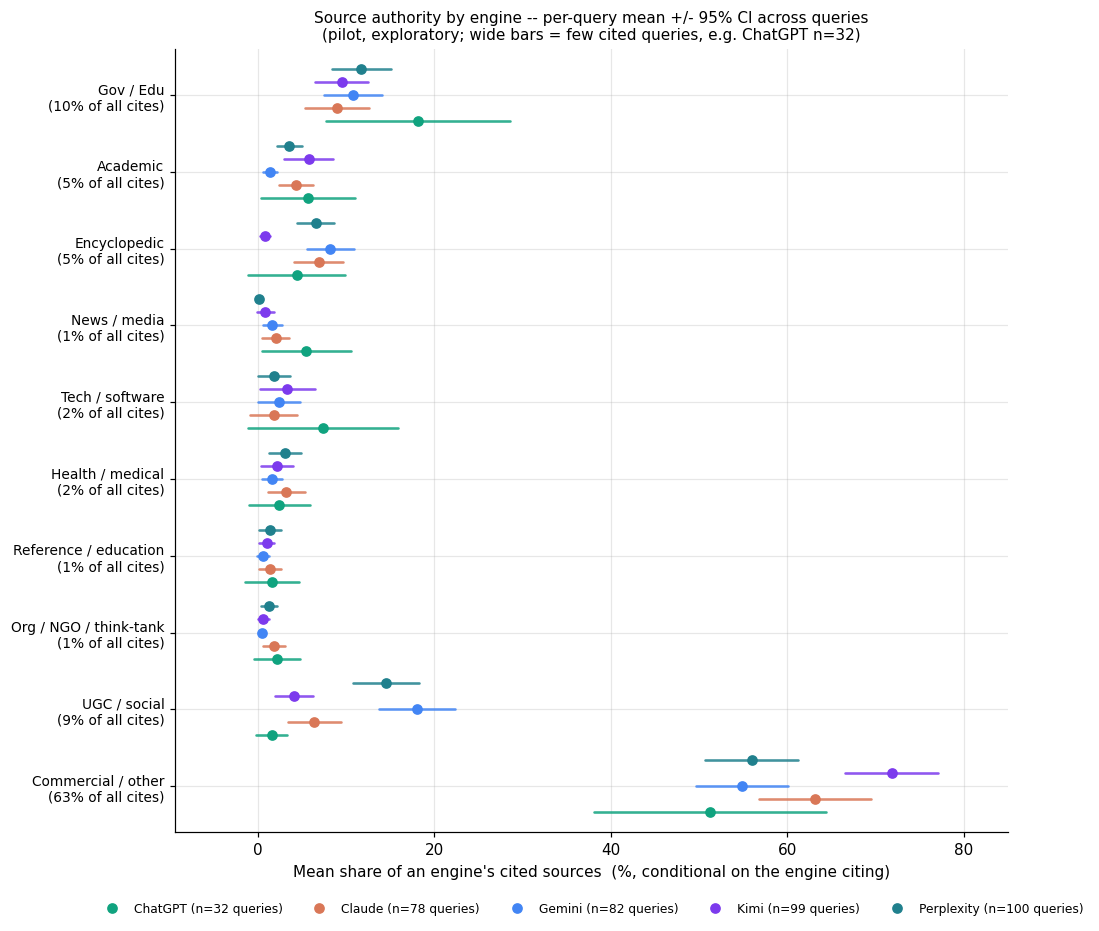

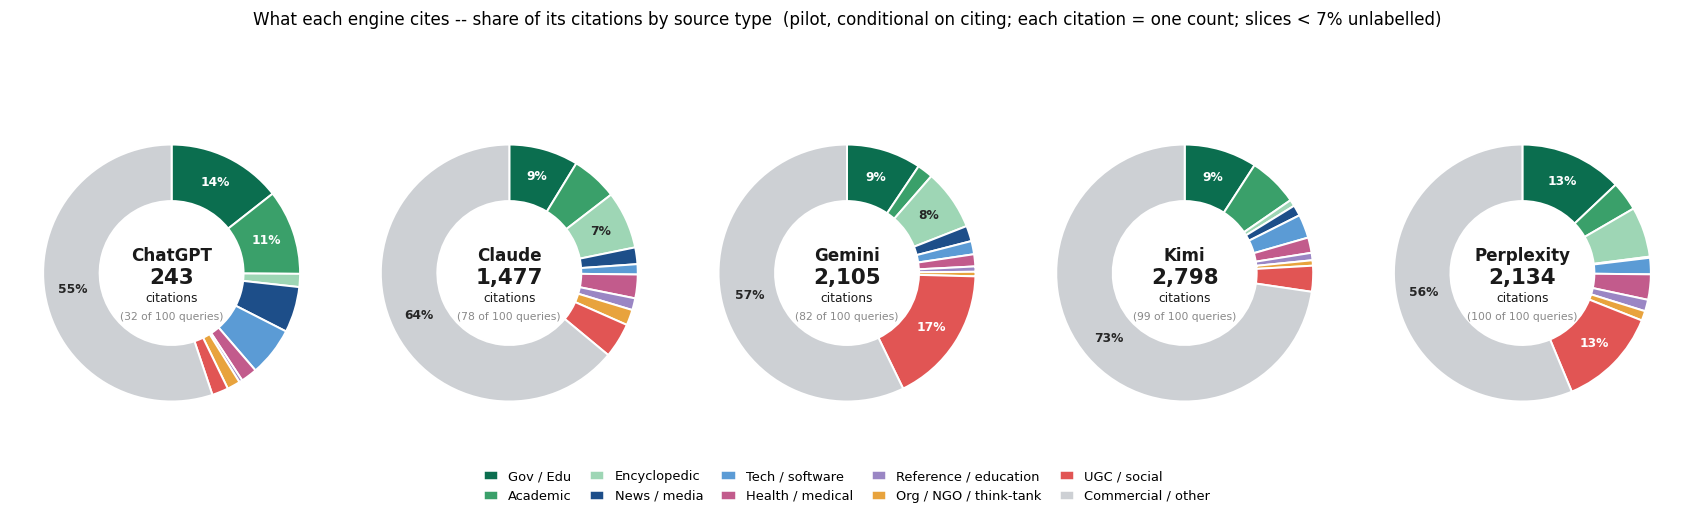

In [26]:
# Fig 1 (rigour): dodged Cleveland dot plot -- tiers x engines, per-query mean +/- 95% CI across
# queries (same uncertainty-aware idiom as cell 4ad1a696). Fig 2 (composition, requested): one DONUT
# per engine, with a grouped colour palette that encodes the authority families.
ybase = {t: i for i, t in enumerate(TIERS)}
dodge = dict(zip(ENGINE_ORDER, np.linspace(0.34, -0.34, len(ENGINE_ORDER))))
fig, ax = plt.subplots(figsize=(10, 8.5))
for (e, t), r in auth.iterrows():
    yy = ybase[t] + dodge[e]
    lo, hi, mn = r["lo"] * 100, r["hi"] * 100, r["mean"] * 100
    if np.isfinite(lo) and np.isfinite(hi):
        ax.plot([lo, hi], [yy, yy], color=ENGINE_COLORS[e], lw=1.7, alpha=.85, solid_capstyle="round")
    ax.plot(mn, yy, "o", color=ENGINE_COLORS[e], ms=6, zorder=3)
ax.set_yticks(range(len(TIERS)))
ax.set_yticklabels([f"{t}\n({pooled[t]:.0f}% of all cites)" for t in TIERS], fontsize=9)
ax.set_ylim(-0.6, len(TIERS) - 0.4); ax.invert_yaxis(); ax.margins(x=0.10)
ax.set_xlabel("Mean share of an engine's cited sources  (%, conditional on the engine citing)")
ax.set_title("Source authority by engine -- per-query mean +/- 95% CI across queries\n"
             "(pilot, exploratory; wide bars = few cited queries, e.g. ChatGPT n=32)", fontsize=10)
handles = [plt.Line2D([0], [0], marker="o", color=ENGINE_COLORS[e], lw=0,
                      label=f"{DISPLAY_NAME[e]} (n={int(nq[e])} queries)") for e in ENGINE_ORDER]
ax.legend(handles=handles, ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.12),
          fontsize=8, frameon=False)
fig.tight_layout(); plt.show()

# Fig 2 (composition, requested): one DONUT per engine = the breakdown of that engine's CITATIONS by
# source type (each distinct cited source counts once; the centre shows the citation total and, in
# grey, how many of the 100 queries those came from). This is the citation-weighted companion to the
# per-query dot plot above. The palette is GROUPED to encode authority families -- greens =
# institutional knowledge (Gov / Academic / Encyclopedic), blues = professional & technical
# (News, Tech), warm = specialist / civil (Health, Reference, Org), red = user-generated, grey =
# long-tail residual. Each slice's % label flips black/white to stay legible; slices < 7% are left to
# the legend to avoid rim clutter.
from matplotlib.patches import Patch
TIER_COLORS = {
    "Gov / Edu": "#0b6e4f", "Academic": "#3aa06a", "Encyclopedic": "#9ed6b5",
    "News / media": "#1d4e89", "Tech / software": "#5b9bd5",
    "Health / medical": "#c25b8c", "Reference / education": "#9a86c4",
    "Org / NGO / think-tank": "#e8a33d",
    "UGC / social": "#e15554", "Commercial / other": "#cdd0d4"}

def _label_color(rgba):
    return "white" if (0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]) < 0.6 else "#262626"

# citation-weighted composition: each distinct cited source = one count
ds = cit.drop_duplicates(["engine", "query_id", "run_index", "url_canonical"])
pool = ds.groupby(["engine", "tier"], observed=True).size().unstack("tier").reindex(ENGINE_ORDER)[TIERS]
ncits = pool.sum(axis=1).astype(int)
pool_pct = pool.div(pool.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, len(ENGINE_ORDER), figsize=(15.5, 4.2))
for ax, e in zip(axes, ENGINE_ORDER):
    wedges, _lab, autos = ax.pie(
        pool_pct.loc[e].values, colors=[TIER_COLORS[t] for t in TIERS], startangle=90,
        counterclock=False, wedgeprops=dict(width=0.44, edgecolor="white", linewidth=1.3),
        autopct=lambda pct: f"{pct:.0f}%" if pct >= 7 else "", pctdistance=0.78,
        textprops=dict(fontsize=8))
    for w, a in zip(wedges, autos):
        a.set_color(_label_color(w.get_facecolor())); a.set_fontweight("bold")
    ax.set(aspect="equal")
    ax.text(0, 0.13, DISPLAY_NAME[e], ha="center", va="center", fontsize=11, fontweight="bold", color="#1a1a1a")
    ax.text(0, -0.04, f"{ncits[e]:,}", ha="center", va="center", fontsize=14, fontweight="bold", color="#1a1a1a")
    ax.text(0, -0.20, "citations", ha="center", va="center", fontsize=8, color="#1a1a1a")
    ax.text(0, -0.34, f"({int(nq[e])} of 100 queries)", ha="center", va="center", fontsize=7, color="#888888")
handles = [Patch(facecolor=TIER_COLORS[t], edgecolor="white", label=t) for t in TIERS]
fig.legend(handles=handles, ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.06),
           fontsize=8.5, frameon=False, handlelength=1.1, columnspacing=1.4)
fig.suptitle("What each engine cites -- share of its citations by source type  "
             "(pilot, conditional on citing; each citation = one count; slices < 7% unlabelled)",
             y=1.03, fontsize=11)
fig.tight_layout(); plt.show()

**What the two figures show.** The **donuts** give each engine's *citation mix* — the share of **all** its citations (centre = citation count) in each source-type tier, counting every citation once. The **dot plot** shows the same composition as a *per-query* mean ± 95% CI across queries; it is query-weighted, so it differs slightly from the citation-weighted donuts — most for ChatGPT, whose mean rests on only 32 cited queries. Both are conditional on the engine citing.

- **`Commercial / other` dominates every engine (≈ 55–73% of citations)** even after carving out health, tech, reference and NGO sources — most AI-search citations are to the long tail of independent and commercial sites (`prelicensetraining.com`, `numberanalytics.com`, `screenrant.com`, `imdb.com`, …). **Kimi is the most long-tail** (≈ 73%), **ChatGPT the least** (≈ 55%).
- **ChatGPT, when it cites, has the most institutional / scholarly / technical mix** — its largest tiers are Gov / Edu (≈ 14%), Academic (≈ 11%) and Tech / software (≈ 6%, mostly official docs: `python.org`, Microsoft Learn), with near-zero UGC (≈ 2%). But this rests on just **243 citations across 32 queries** (the ~72% zero-citation floor), so read it as exploratory.
- **Gemini and Perplexity lean hardest on UGC / social** (≈ 17% and ≈ 13% of citations — YouTube and Reddit dominate that tier), the two most aggressive retrievers.
- **Health / medical is a small but YMYL-sensitive slice** (≈ 2–3%) carried by *consumer-health publishers* (WebMD, Healthline, Cleveland Clinic, Mayo Clinic) rather than the primary literature in Academic.
- **Kimi barely touches encyclopedic sources** (≈ 0.8% vs 6–8% for Gemini / Perplexity) and tilts hardest toward the commercial long tail.

**Caveats.** (1) *Conditional on citing*, and citation volume varies ~12× across engines (ChatGPT 243 → Kimi 2,798), so ChatGPT's mix is by far the least certain. (2) Tiers are a proxy for **source type / function, not article quality or factual correctness**: a WebMD page and a journal article both inform, differently. (3) The classifier is rule-based and conservative; the carved tiers rest on curated domain lists, while `Commercial / other` is a residual the lists cannot fully resolve (its long tail is 2,500+ domains, top-100 only ≈ 19% of the mass) — so the carved tiers *undercount* and `Commercial / other` is an upper bound. (4) AIS is **not** attributed per tier here (sentence support is response-level), so this section describes *what* engines cite, not whether their high-authority citations are better supported — that join is deferred to the scale-up.

## 11 · Synthesis

The pilot was conceived as a proof-of-protocol — a 100-query, k = 3, five-engine validation pass on
the measurement design that the scale-up will inherit at 250 queries and k = 8. Three findings
emerge.

### 11.1 · Protocol findings

The artifact is a complete 100 × 5 × 3 factorial: 1,500 rows, no duplicate or missing cells. PAWC is
computed deterministically per call; AIS is computed by an external NLI model applied uniformly across
all five engines. One row carries an undefined AIS rate (a Gemini cell with zero sentences); the
derived CV is undefined for 117 of the 500 (engine × query) cells (23.4%), corresponding to cells
where the engine returned zero PAWC across all three repeats. Both are analytically informative rather
than measurement failures. The protocol is stable enough to serve as the analysis foundation for the
scale-up.

### 11.2 · Engine findings

Three search-behaviour bands separate the five engines: always-on retrieval (Perplexity 100%,
Kimi 98%), mostly-on (Claude 74%, Gemini 70%), and off-by-default (ChatGPT 28%). The bands are not
preferences but constitutive of the cross-engine comparison: unconditional PAWC and AIS conflate two
distinct questions — whether the engine chose to retrieve, and how well it used what it retrieved.
Conditioning on the cells where the engine searched lifts ChatGPT's PAWC roughly threefold
(56 → 174) and its AIS rate from 0.14 to 0.44, while the other four engines move far less.
Conditioning compresses the top of the AIS leaderboard rather than crowning one leader — Kimi (0.79),
Claude (0.79) and Perplexity (0.78) converge — with Claude posting the largest conditional gain
(0.61 → 0.79), indicating that when it retrieves and cites, its citations are unusually well-supported.
PAWC's position weighting is empirically justified: the first five source positions account for 20.7%
of total supported-word mass, and half the mass is covered by position 12.
A complementary view — *what* the engines cite (§10) — reinforces this conditional story from the other side: on the few queries where ChatGPT does cite, it draws the most authoritative mix (≈ 28% government / academic / encyclopedic, near-zero user-generated content), whereas the aggressive retrievers Gemini and Perplexity source ≈ 15–18% of their citations from YouTube and Reddit.

### 11.3 · Scale-up implications

Three properties of the pilot data signal what the scale-up must address. **First**, the √3 ≈ 1.732
ceiling at k = 3 is reached by ~9% of eligible cells (and 30% of ChatGPT's), particularly where
retrieval is binary; the scale-up's k = 8 design is empirically justified by this evidence and
consistent with the k ≥ 7 minimum recommended by Schulte et al. (2026). **Second**, Perplexity's
single-block segmentation (median 84.5 words/sentence) depresses its sentence-level AIS denominator
and is not directly comparable to the four sentence-segmenting engines; the scale-up should either
adopt a uniform segmentation step or report Perplexity AIS with explicit denominator notes. **Third**, fetch attrition is a second-stage measurement risk: the diagnostic file documented in
the methods chapter shows non-trivial drop-off between cited URLs and successfully fetched content
for ChatGPT under forced search, and the scale-up should monitor this rate across all five engines
rather than assuming citation count equals retrievable content count.

*What the pilot deliberately does not do:* no formal inference (n is too small once the conditional
view restricts ChatGPT to 32 cells), no matched-design subset, no three-way engine × domain × intent
breakdown, no multiple-comparison correction, and no cost/token analysis (the token columns are zero
here; cost lives in a separate ledger). Each is deferred to the scale-up, where the larger sample
will support it.